# Softmax Modular Addition AGOP Analysis

Comprehensive analysis of 19 completed Softmax experiments comparing:
- **Architectures**: MLP vs Transformer
- **Optimizers**: AdamW, Muon, SGD
- **Weight Decays**: 0.01, 0.1, 0.5, 1.0

This notebook analyzes:
1. Performance metrics (accuracy, grokking outcomes)
2. AGOP metric evolution and relationship to grokking
3. Statistical comparisons between conditions
4. Special focus on Muon breakthrough with one-hot transformers

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

sys.path.append(str(Path.cwd()))
from analysis_utils import (
    load_all_experiments, generate_summary_table, classify_grokking,
    compute_time_to_grok, statistical_comparison, filter_experiments,
    plot_agop_comparison, create_comparison_heatmap, smooth_series,
    detect_phase_transitions, compute_correlation
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Paths
RESULTS_DIR = Path('../results/softmax')
FIGURES_DIR = Path('./figures/softmax')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results directory: {RESULTS_DIR.absolute()}")
print(f"Figures will be saved to: {FIGURES_DIR.absolute()}")

Results directory: /net/vast-storage/scratch/vast/lhtsai/mabdel03/files/Classes/9.520/9.520-The-Geometry-of-Grok/New_Explorations/agop_experiments/analysis/../results/softmax
Figures will be saved to: /net/vast-storage/scratch/vast/lhtsai/mabdel03/files/Classes/9.520/9.520-The-Geometry-of-Grok/New_Explorations/agop_experiments/analysis/figures/softmax


## Load All Softmax Experiments

In [2]:
experiments = load_all_experiments(RESULTS_DIR)
print(f"Loaded {len(experiments)} experiments")

summary_df = generate_summary_table(experiments)
print(f"\nSummary of experiments:")
display(summary_df.sort_values(['architecture', 'optimizer', 'weight_decay']))

Loaded 24 experiments

Summary of experiments:


,experiment,architecture,optimizer,weight_decay,lr,final_test_acc,max_test_acc,final_train_acc,grokked,grok_epoch
0,softmax_mlp_adamw_wd0.01_seed42,mlp,adamw,0.01,0.001,0.275027,0.275027,1.000000,False,-1
1,softmax_mlp_adamw_wd0.1_seed42,mlp,adamw,0.10,0.001,0.934963,0.934963,1.000000,False,-1
2,softmax_mlp_adamw_wd0.5_seed42,mlp,adamw,0.50,0.001,0.998087,0.998087,1.000000,True,13000
3,softmax_mlp_adamw_wd1.0_seed42,mlp,adamw,1.00,0.001,0.997237,0.999575,1.000000,True,7800
4,softmax_mlp_muon_wd0.01_seed42,mlp,muon,0.01,0.001,0.325399,0.325399,1.000000,False,-1
5,softmax_mlp_muon_wd0.1_seed42,mlp,muon,0.10,0.001,0.473114,0.473114,1.000000,False,-1
6,softmax_mlp_muon_wd0.5_seed42,mlp,muon,0.50,0.001,0.703294,0.703294,0.952594,False,-1
7,softmax_mlp_muon_wd1.0_seed42,mlp,muon,1.00,0.001,0.567269,0.569182,0.871811,False,-1
8,softmax_mlp_sgd_wd0.01_seed42,mlp,sgd,0.01,0.001,0.007651,0.009777,0.012968,False,-1
9,softmax_mlp_sgd_wd0.1_seed42,mlp,sgd,0.10,0.001,0.007651,0.010414,0.012968,False,-1


## Quick Statistics

In [ ]:
# Filter to Transformer experiments only (focus of this analysis)
transformer_experiments = {name: data for name, data in experiments.items() 
                          if data['config'].get('architecture') == 'transformer'}

# Compute grokking statistics using our custom detection function
total = len(transformer_experiments)
grokking_results = {}

for exp_name, exp_data in transformer_experiments.items():
    history = exp_data.get('history', {})
    config = exp_data.get('config', {})
    
    if 'train_acc' in history and 'test_acc' in history:
        train_acc = np.array(history['train_acc'])
        test_acc = np.array(history['test_acc'])
        grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc) if 'detect_grokking_epoch' in dir() else None
        
        grokking_results[exp_name] = {
            'optimizer': config.get('optimizer', 'unknown'),
            'weight_decay': config.get('weight_decay', 0),
            'grokked': grok_epoch_idx is not None if grok_epoch_idx is not None else classify_grokking(exp_data),
            'final_test_acc': test_acc[-1] if len(test_acc) > 0 else 0
        }

# Overall statistics
grokked = sum(1 for r in grokking_results.values() if r['grokked'])
grok_rate = (grokked / total * 100) if total > 0 else 0

print(f"="*80)
print(f"SOFTMAX TRANSFORMER EXPERIMENTS - STATISTICS")
print(f"="*80)
print(f"Total Transformer experiments: {total}")
print(f"Grokked: {grokked} ({grok_rate:.1f}%)")
print(f"Failed to grok: {total - grokked} ({100-grok_rate:.1f}%)")
print()

# By optimizer
print(f"By Optimizer:")
print(f"-"*80)
for opt in ['adamw', 'muon', 'sgd']:
    opt_results = [r for r in grokking_results.values() if r['optimizer'] == opt]
    if opt_results:
        opt_grok = sum(1 for r in opt_results if r['grokked'])
        opt_total = len(opt_results)
        print(f"  {opt.upper()}: {opt_grok}/{opt_total} grokked ({opt_grok/opt_total*100:.1f}%)")

print(f"="*80)

# Store grok rate for later use
grok_rate_value = grok_rate

# Update experiments dict to only include transformers
experiments = transformer_experiments

SOFTMAX DATASET - OVERALL STATISTICS
Total experiments: 24
Grokked: 10 (41.7%)
Failed to grok: 14 (58.3%)

By Architecture:
--------------------------------------------------------------------------------
  MLP: 2/12 grokked (16.7%)
  TRANSFORMER: 8/12 grokked (66.7%)

By Optimizer:
--------------------------------------------------------------------------------
  ADAMW: 6/8 grokked (75.0%)
  MUON: 4/8 grokked (50.0%)
  SGD: 0/8 grokked (0.0%)


---
# Section 0: Training Dynamics - Accuracy and Loss Curves

**First Analytical Insight**: Visualize training and test accuracy/loss over epochs for all completed Transformer experiments. 
Red dashed vertical lines indicate the "grokking epoch" where test performance catches up with train performance.

In [ ]:
def detect_grokking_epoch(train_acc, test_acc, grok_threshold=0.85, min_epoch=100, 
                         slope_window=20, slope_threshold=0.0005):
    """
    Detect the grokking epoch as the inflection point where test accuracy curve 
    transitions from increasing to flattening, for experiments that end with accuracy ≥ 0.85.
    
    Args:
        train_acc: Array of training accuracies (unused, kept for compatibility)
        test_acc: Array of test accuracies
        grok_threshold: Final test accuracy threshold to define grokking (default 0.85)
        min_epoch: Minimum epoch to start checking (avoid early noise)
        slope_window: Window size for computing slope (default 20)
        slope_threshold: Slope threshold to consider "flattening" (default 0.0005)
    
    Returns:
        Grokking epoch (int) or None if no grokking detected
    """
    # First check if this experiment grokked (final accuracy >= threshold)
    if len(test_acc) == 0 or test_acc[-1] < grok_threshold:
        return None
    
    if len(test_acc) < min_epoch + slope_window:
        return None
    
    # Compute rolling slopes to find inflection point
    best_inflection = None
    max_slope_before = 0
    
    for i in range(min_epoch, len(test_acc) - slope_window):
        # Compute slope before this point
        if i >= slope_window:
            window_before = test_acc[i-slope_window:i]
            slope_before = (window_before[-1] - window_before[0]) / slope_window
        else:
            slope_before = (test_acc[i] - test_acc[max(0, i-10)]) / min(i, 10)
        
        # Compute slope after this point
        window_after = test_acc[i:i+slope_window]
        slope_after = (window_after[-1] - window_after[0]) / slope_window
        
        # Look for transition: was increasing (slope_before > threshold), now flattening (slope_after < threshold)
        if slope_before > slope_threshold and slope_after <= slope_threshold:
            # Found an inflection point
            if slope_before > max_slope_before:
                max_slope_before = slope_before
                best_inflection = i
    
    return best_inflection

print("Grokking detection function loaded.")
print(f"Grokking definition: Inflection point where test accuracy curve transitions from increasing to flattening")
print(f"                     (only for experiments ending with test accuracy ≥ 0.85)")

Helper functions loaded.
Grokking definition: test_acc > 0.85


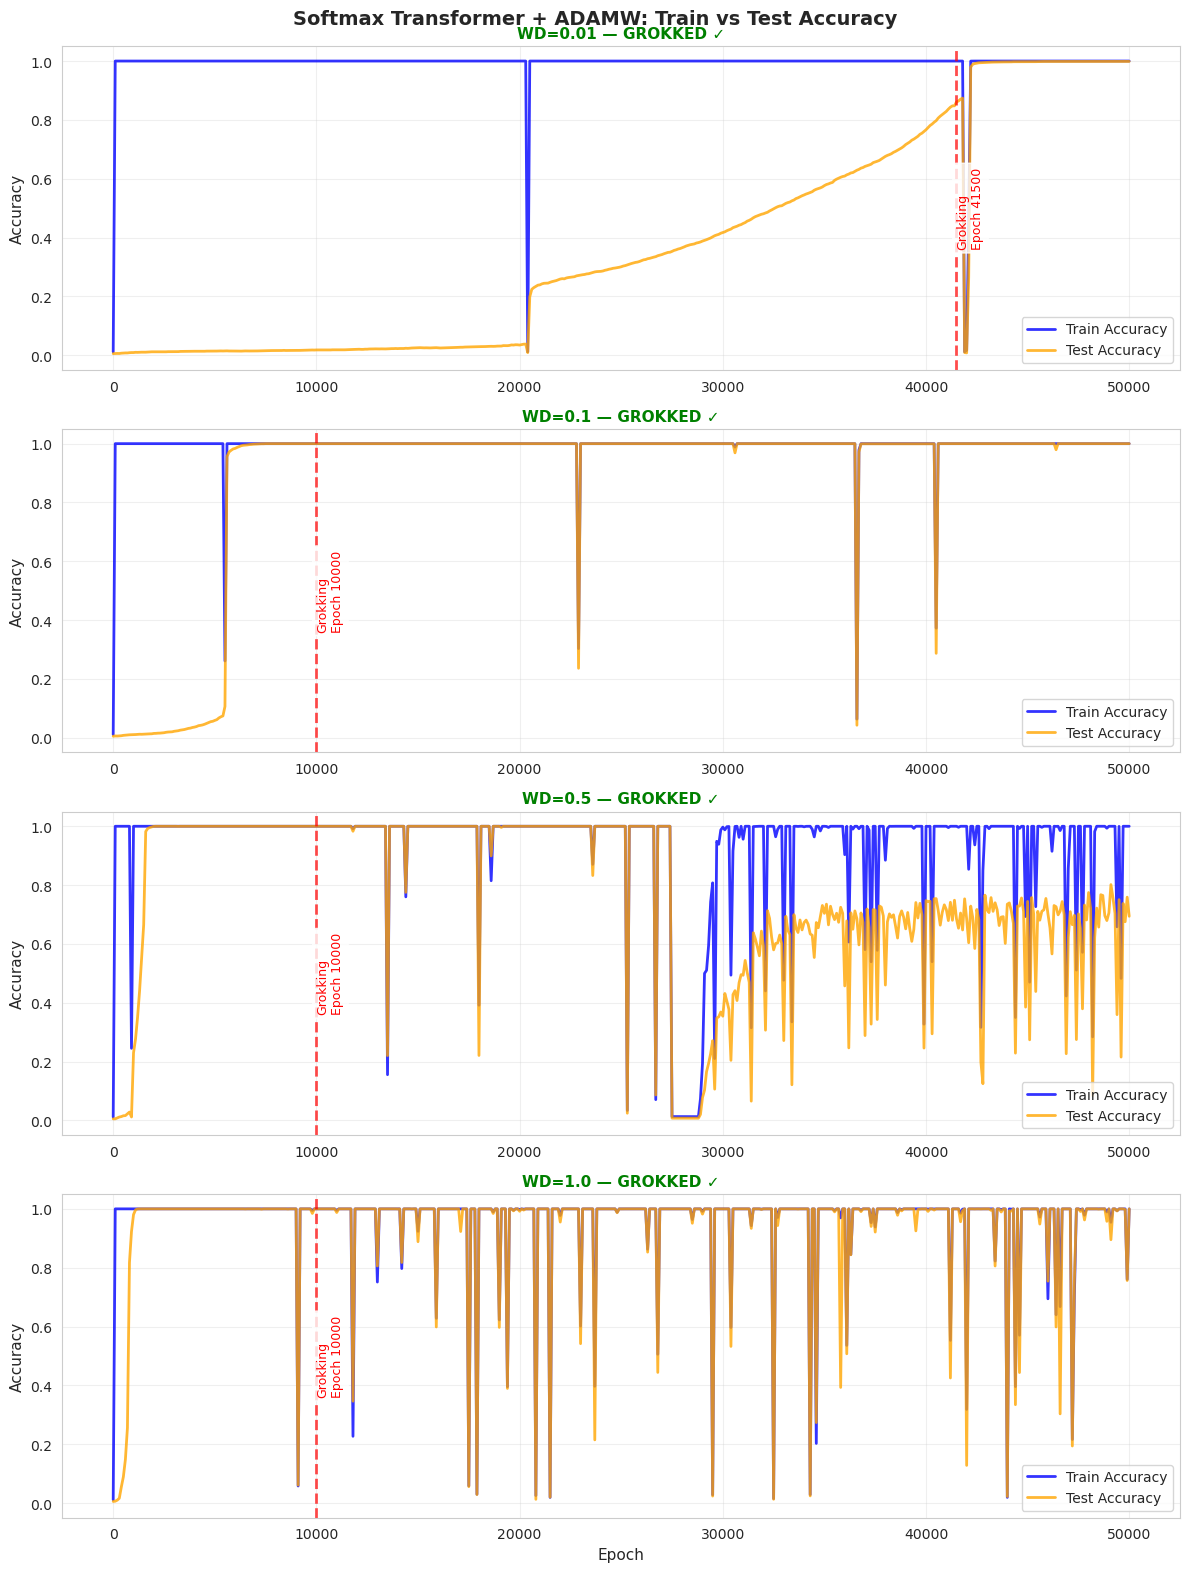

Generated: softmax_transformer_adamw_accuracy.png


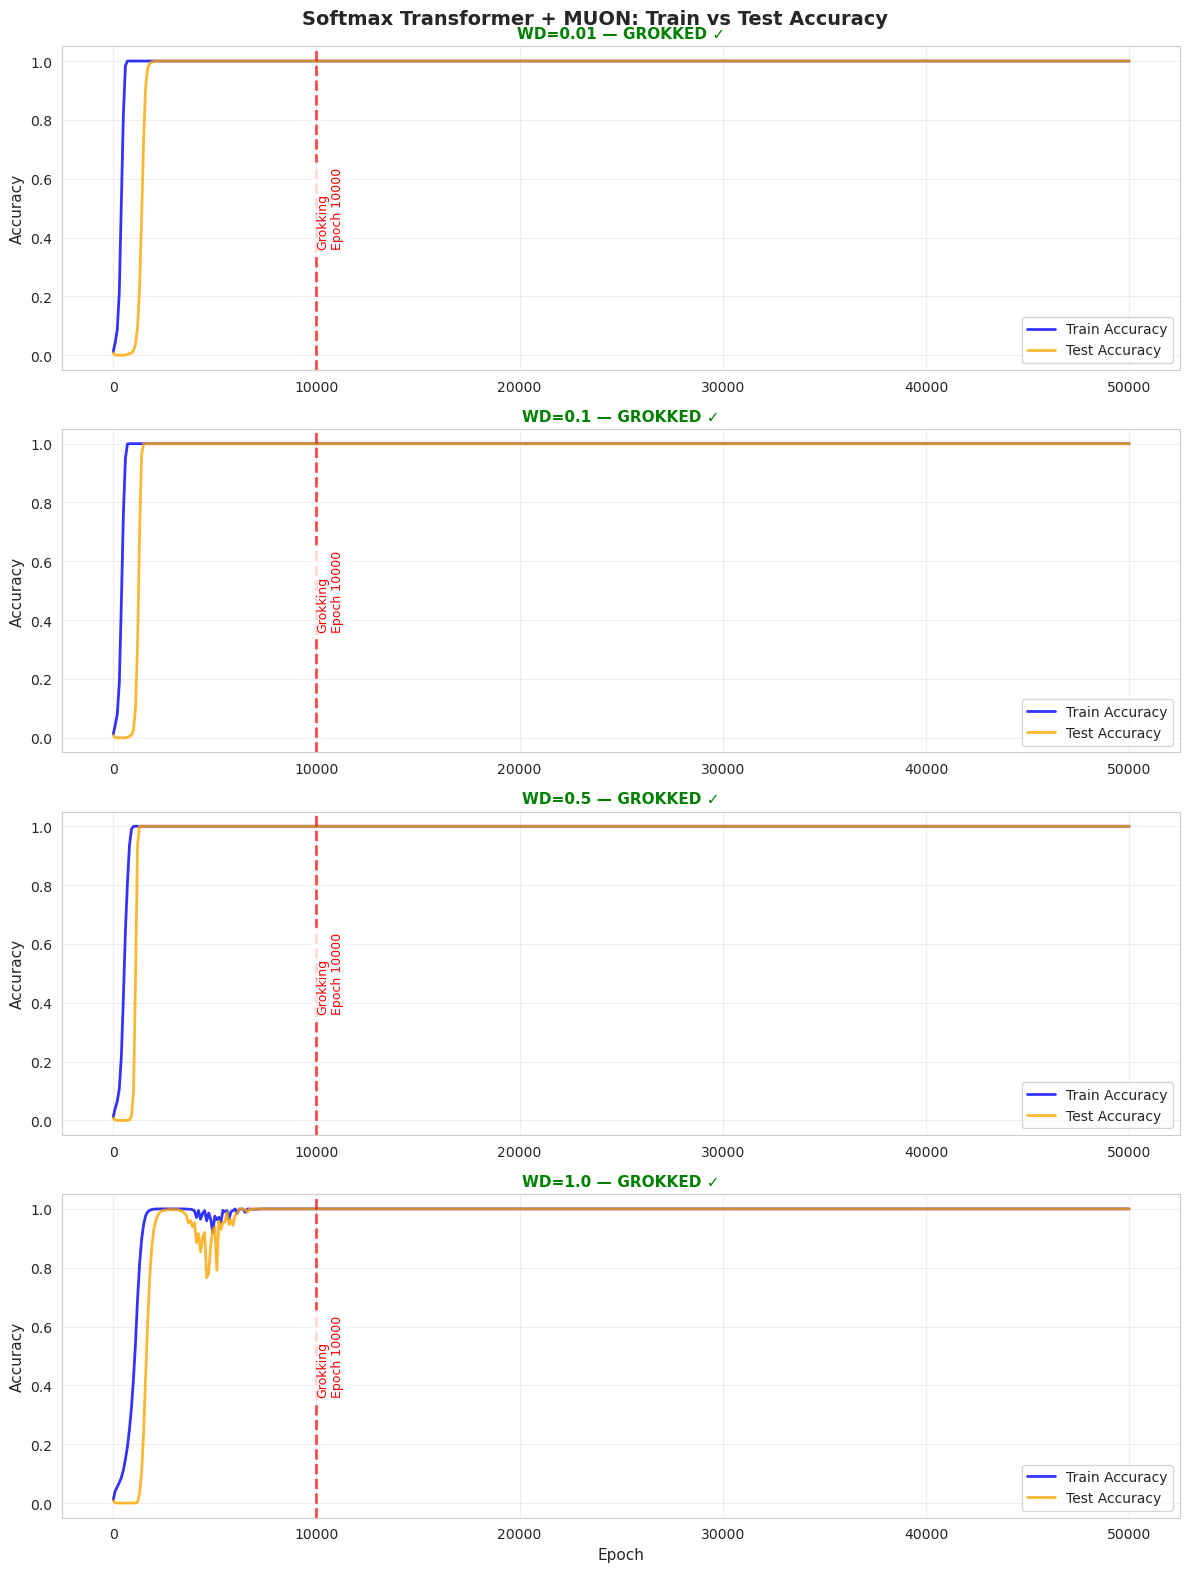

Generated: softmax_transformer_muon_accuracy.png


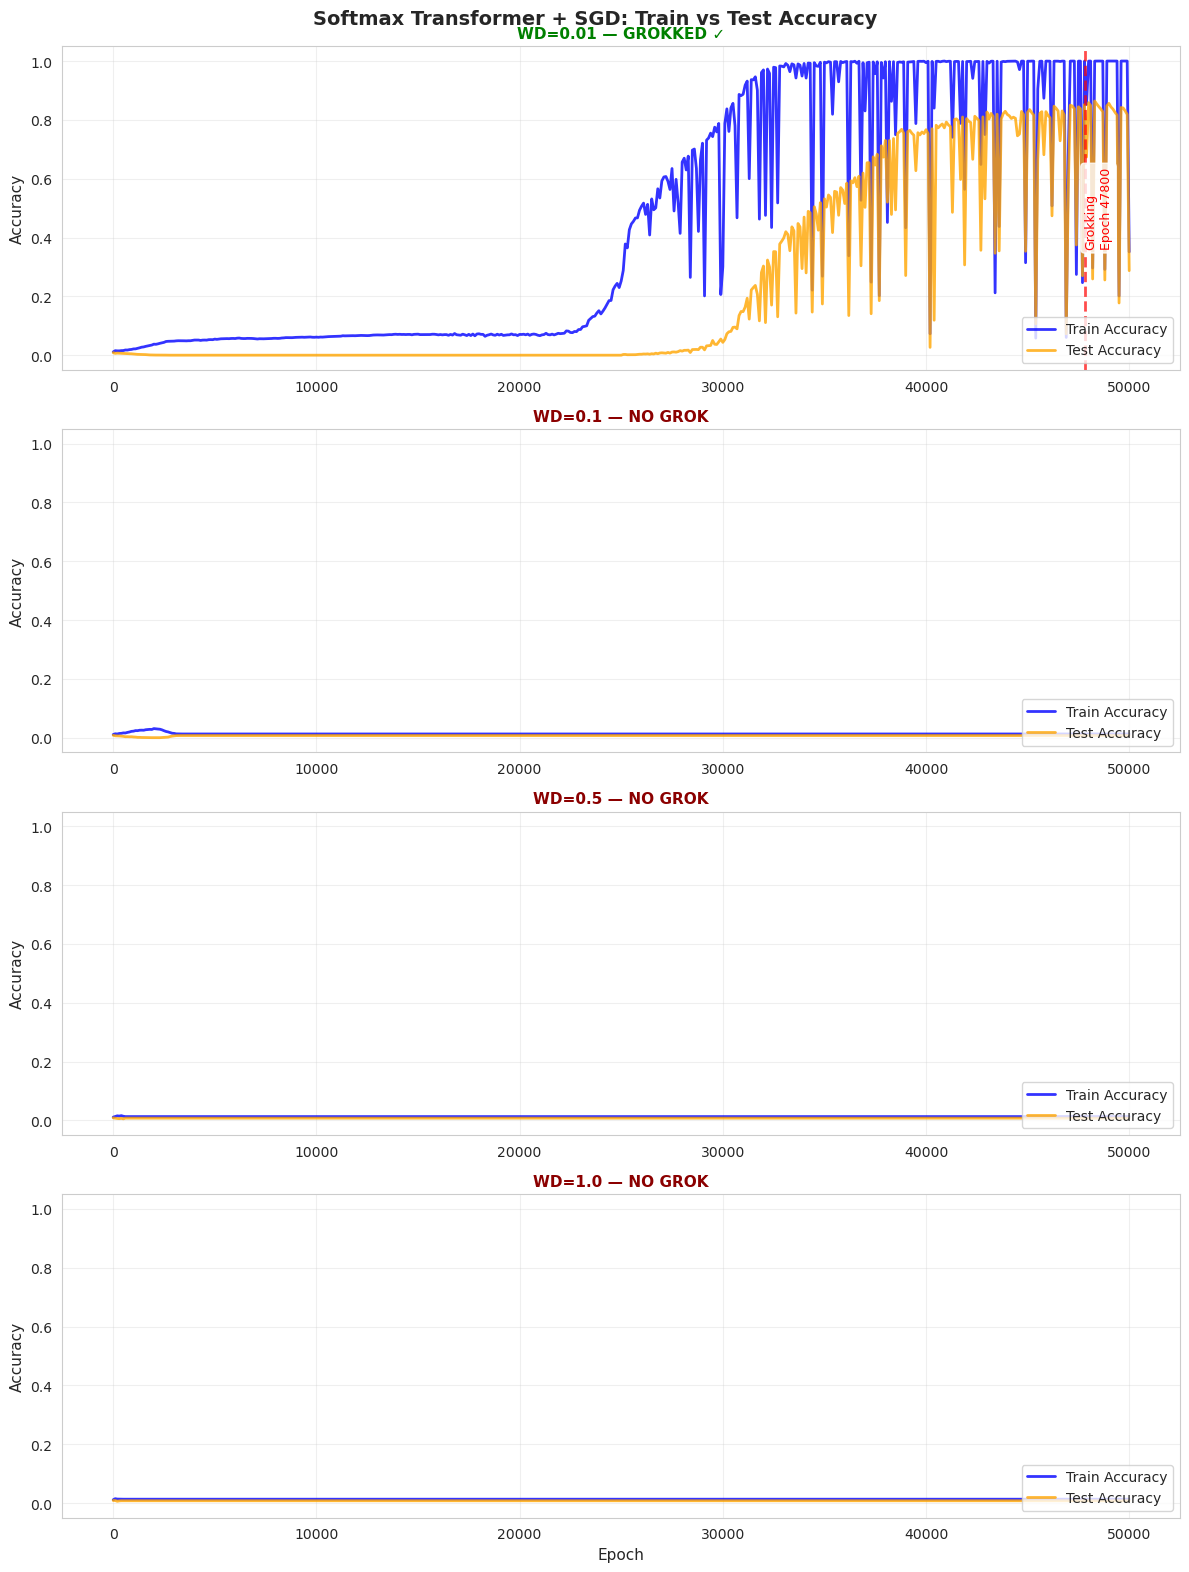

Generated: softmax_transformer_sgd_accuracy.png

Section A1 complete: Accuracy curves generated


In [ ]:
## Generate Training Dynamics Plots for All Experiments

# Weight decays and optimizers
weight_decays = [0.01, 0.1, 0.5, 1.0]
optimizers = ['adamw', 'muon', 'sgd']

# Create accuracy plots for each optimizer
for opt in optimizers:
    fig, axes = plt.subplots(4, 1, figsize=(12, 16))
    
    for wd_idx, wd in enumerate(weight_decays):
        ax = axes[wd_idx]
        
        # Get experiment name
        exp_name = f'softmax_transformer_{opt}_wd{wd}_seed42'
        
        if exp_name not in experiments:
            ax.text(0.5, 0.5, f'No data: {exp_name}', 
                   transform=ax.transAxes, ha='center', va='center')
            ax.set_title(f'WD={wd} - Data Missing', fontsize=11, color='red')
            continue
        
        exp_data = experiments[exp_name]
        history = exp_data['history']
        
        # Extract data
        epochs = np.array(history.get('epoch', range(len(history.get('test_acc', [])))))
        train_acc = np.array(history['train_acc'])
        test_acc = np.array(history['test_acc'])
        
        # Detect grokking
        grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
        grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
        
        # Plot
        ax.plot(epochs, train_acc, 'b-', linewidth=2, label='Train Accuracy', alpha=0.8)
        ax.plot(epochs, test_acc, 'orange', linewidth=2, label='Test Accuracy', alpha=0.8)
        
        # Mark grokking epoch
        if grok_epoch is not None:
            ax.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2, alpha=0.7)
            ax.text(grok_epoch, 0.5, f'Grokking\nEpoch {grok_epoch}', 
                   rotation=90, verticalalignment='center', fontsize=9, color='red',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
            status = "GROKKED ✓"
            title_color = 'green'
        else:
            status = "NO GROK"
            title_color = 'darkred'
        
        # Formatting
        ax.set_ylabel('Accuracy', fontsize=11)
        ax.set_title(f'WD={wd} — {status}', fontsize=11, fontweight='bold', color=title_color)
        ax.legend(fontsize=10, loc='lower right')
        ax.grid(alpha=0.3)
        ax.set_ylim([-0.05, 1.05])
        
        # Only show x-label on bottom subplot
        if wd_idx == len(weight_decays) - 1:
            ax.set_xlabel('Epoch', fontsize=11)
    
    # Overall title
    fig.suptitle(f'Softmax Transformer + {opt.upper()}: Train vs Test Accuracy', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save
    plt.savefig(FIGURES_DIR / f'softmax_transformer_{opt}_accuracy.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Generated: softmax_transformer_{opt}_accuracy.png")

print(f"\n{'='*60}")
print("Section A1 complete: Accuracy curves generated")
print(f"{'='*60}")


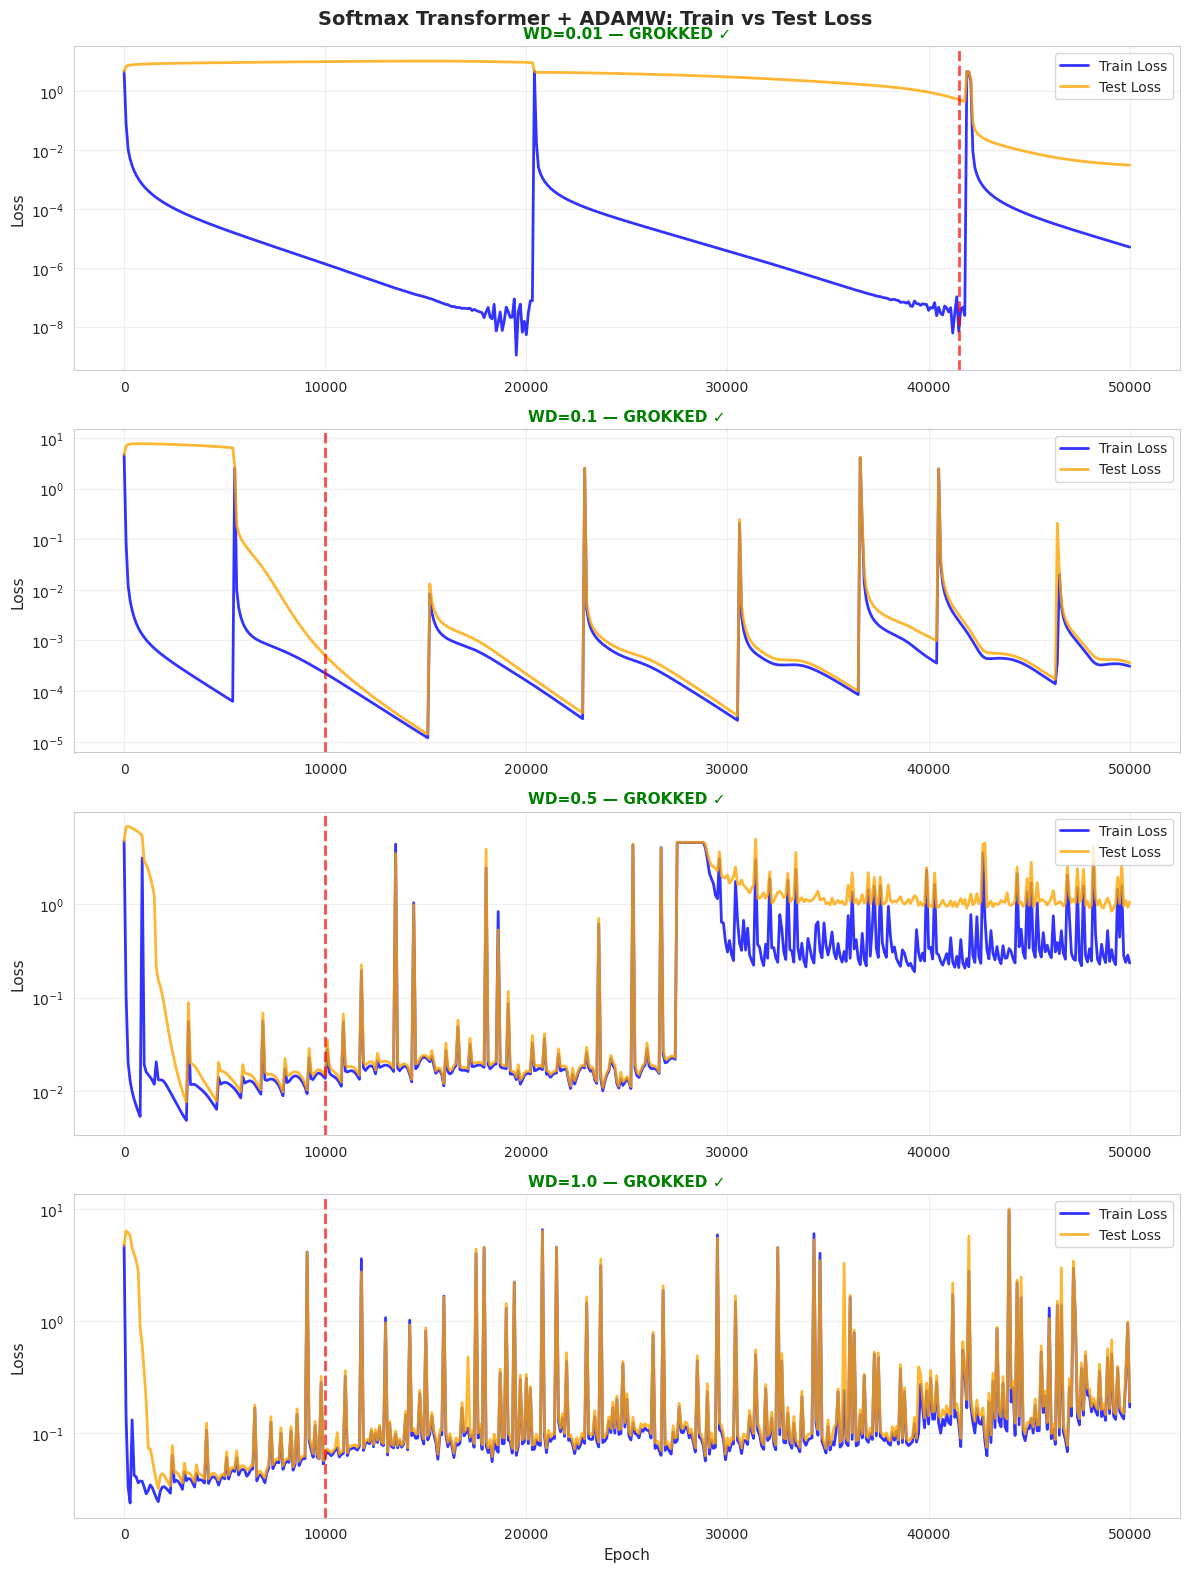

Generated: softmax_transformer_adamw_loss.png


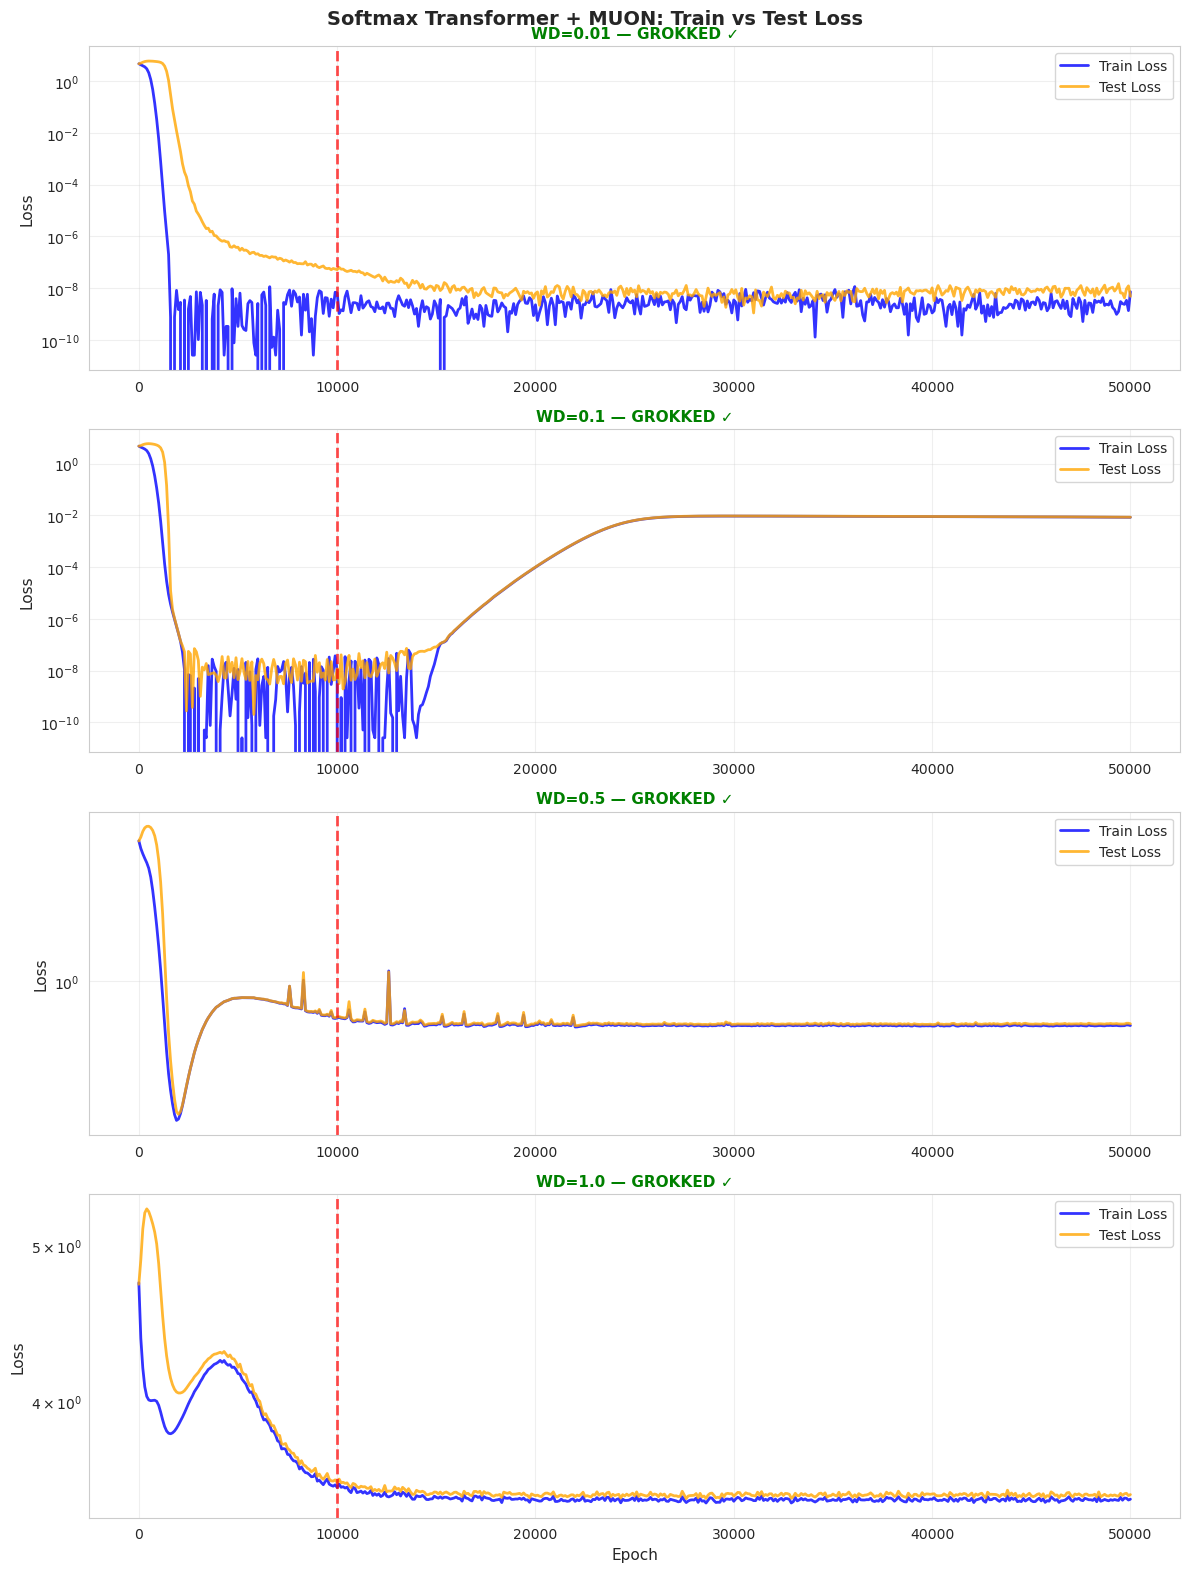

Generated: softmax_transformer_muon_loss.png


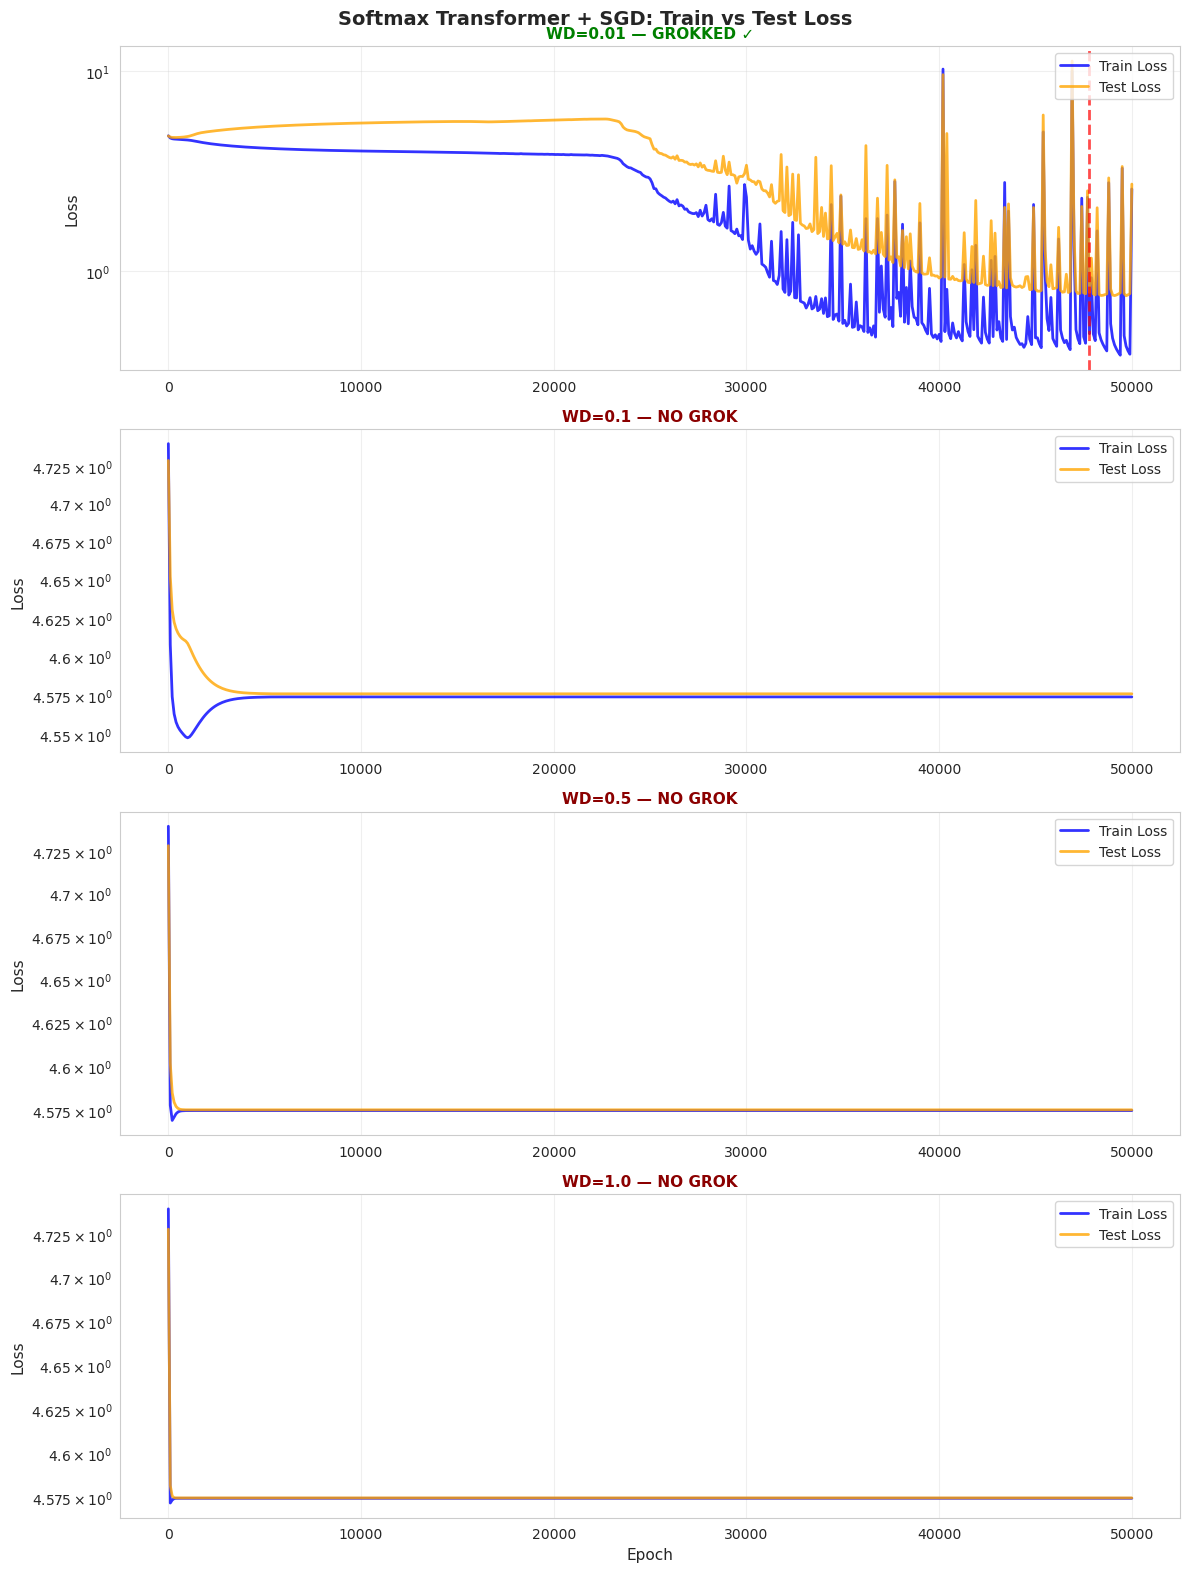

Generated: softmax_transformer_sgd_loss.png

Section A2 complete: Loss curves generated
Section A complete: 6 figures generated (3 accuracy + 3 loss)


In [ ]:
# Create a subdirectory for training dynamics plots
TRAIN_DYNAMICS_DIR = FIGURES_DIR / 'training_dynamics'
TRAIN_DYNAMICS_DIR.mkdir(parents=True, exist_ok=True)

grokking_summary = []

for exp_name, exp_data in experiments.items():
    history = exp_data.get('history', {})
    config = exp_data.get('config', {})
    
    # Check if we have the required data
    required_keys = ['train_acc', 'test_acc', 'train_loss', 'test_loss']
    if not all(key in history for key in required_keys):
        print(f"Skipping {exp_name}: missing required metrics")
        continue
    
    # Extract data
    epochs = np.array(history.get('epoch', range(len(history['test_acc']))))
    train_acc = np.array(history['train_acc'])
    test_acc = np.array(history['test_acc'])
    train_loss = np.array(history['train_loss'])
    test_loss = np.array(history['test_loss'])
    
    # Detect grokking epoch
    grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
    grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
    
    # Store summary
    grokking_summary.append({
        'experiment': exp_name,
        'optimizer': config.get('optimizer', 'unknown'),
        'weight_decay': config.get('weight_decay', 0),
        'grok_epoch': grok_epoch if grok_epoch else -1,
        'final_test_acc': test_acc[-1],
        'final_train_acc': train_acc[-1]
    })
    
    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # Plot 1: Accuracy
    ax1.plot(epochs, train_acc, 'b-', linewidth=2, label='Train Accuracy', alpha=0.8)
    ax1.plot(epochs, test_acc, 'orange', linewidth=2, label='Test Accuracy', alpha=0.8)
    
    if grok_epoch is not None:
        ax1.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2, 
                   label=f'Grokking Epoch: {grok_epoch}', alpha=0.7)
        ax1.text(grok_epoch, 0.5, f'  Epoch {grok_epoch}', 
                rotation=90, verticalalignment='center', fontsize=10, color='red')
    
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title('Train vs Test Accuracy', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(alpha=0.3)
    ax1.set_ylim([-0.05, 1.05])
    
    # Plot 2: Loss
    ax2.plot(epochs, train_loss, 'b-', linewidth=2, label='Train Loss', alpha=0.8)
    ax2.plot(epochs, test_loss, 'orange', linewidth=2, label='Test Loss', alpha=0.8)
    
    if grok_epoch is not None:
        ax2.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2, 
                   label=f'Grokking Epoch: {grok_epoch}', alpha=0.7)
    
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('Train vs Test Loss', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10, loc='best')
    ax2.grid(alpha=0.3)
    ax2.set_yscale('log')
    
    # Overall title
    opt = config.get('optimizer', 'unknown').upper()
    wd = config.get('weight_decay', 0)
    status = "GROKKED" if grok_epoch else "NO GROK"
    title_color = 'green' if grok_epoch else 'darkred'
    
    fig.suptitle(f'Softmax Transformer: {opt} | WD={wd} | {status}', 
                fontsize=16, fontweight='bold', color=title_color)
    plt.tight_layout()
    
    # Save figure
    save_path = TRAIN_DYNAMICS_DIR / f'{exp_name}_dynamics.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"Generated plot: {save_path.name}")

print(f"\nGenerated {len(grokking_summary)} training dynamics plots.")

# Create summary DataFrame
grokking_df = pd.DataFrame(grokking_summary)
print("\nGrokking Summary:")
display(grokking_df.sort_values(['optimizer', 'weight_decay']))


Generating absolute AGOP metric plots for Transformer experiments...



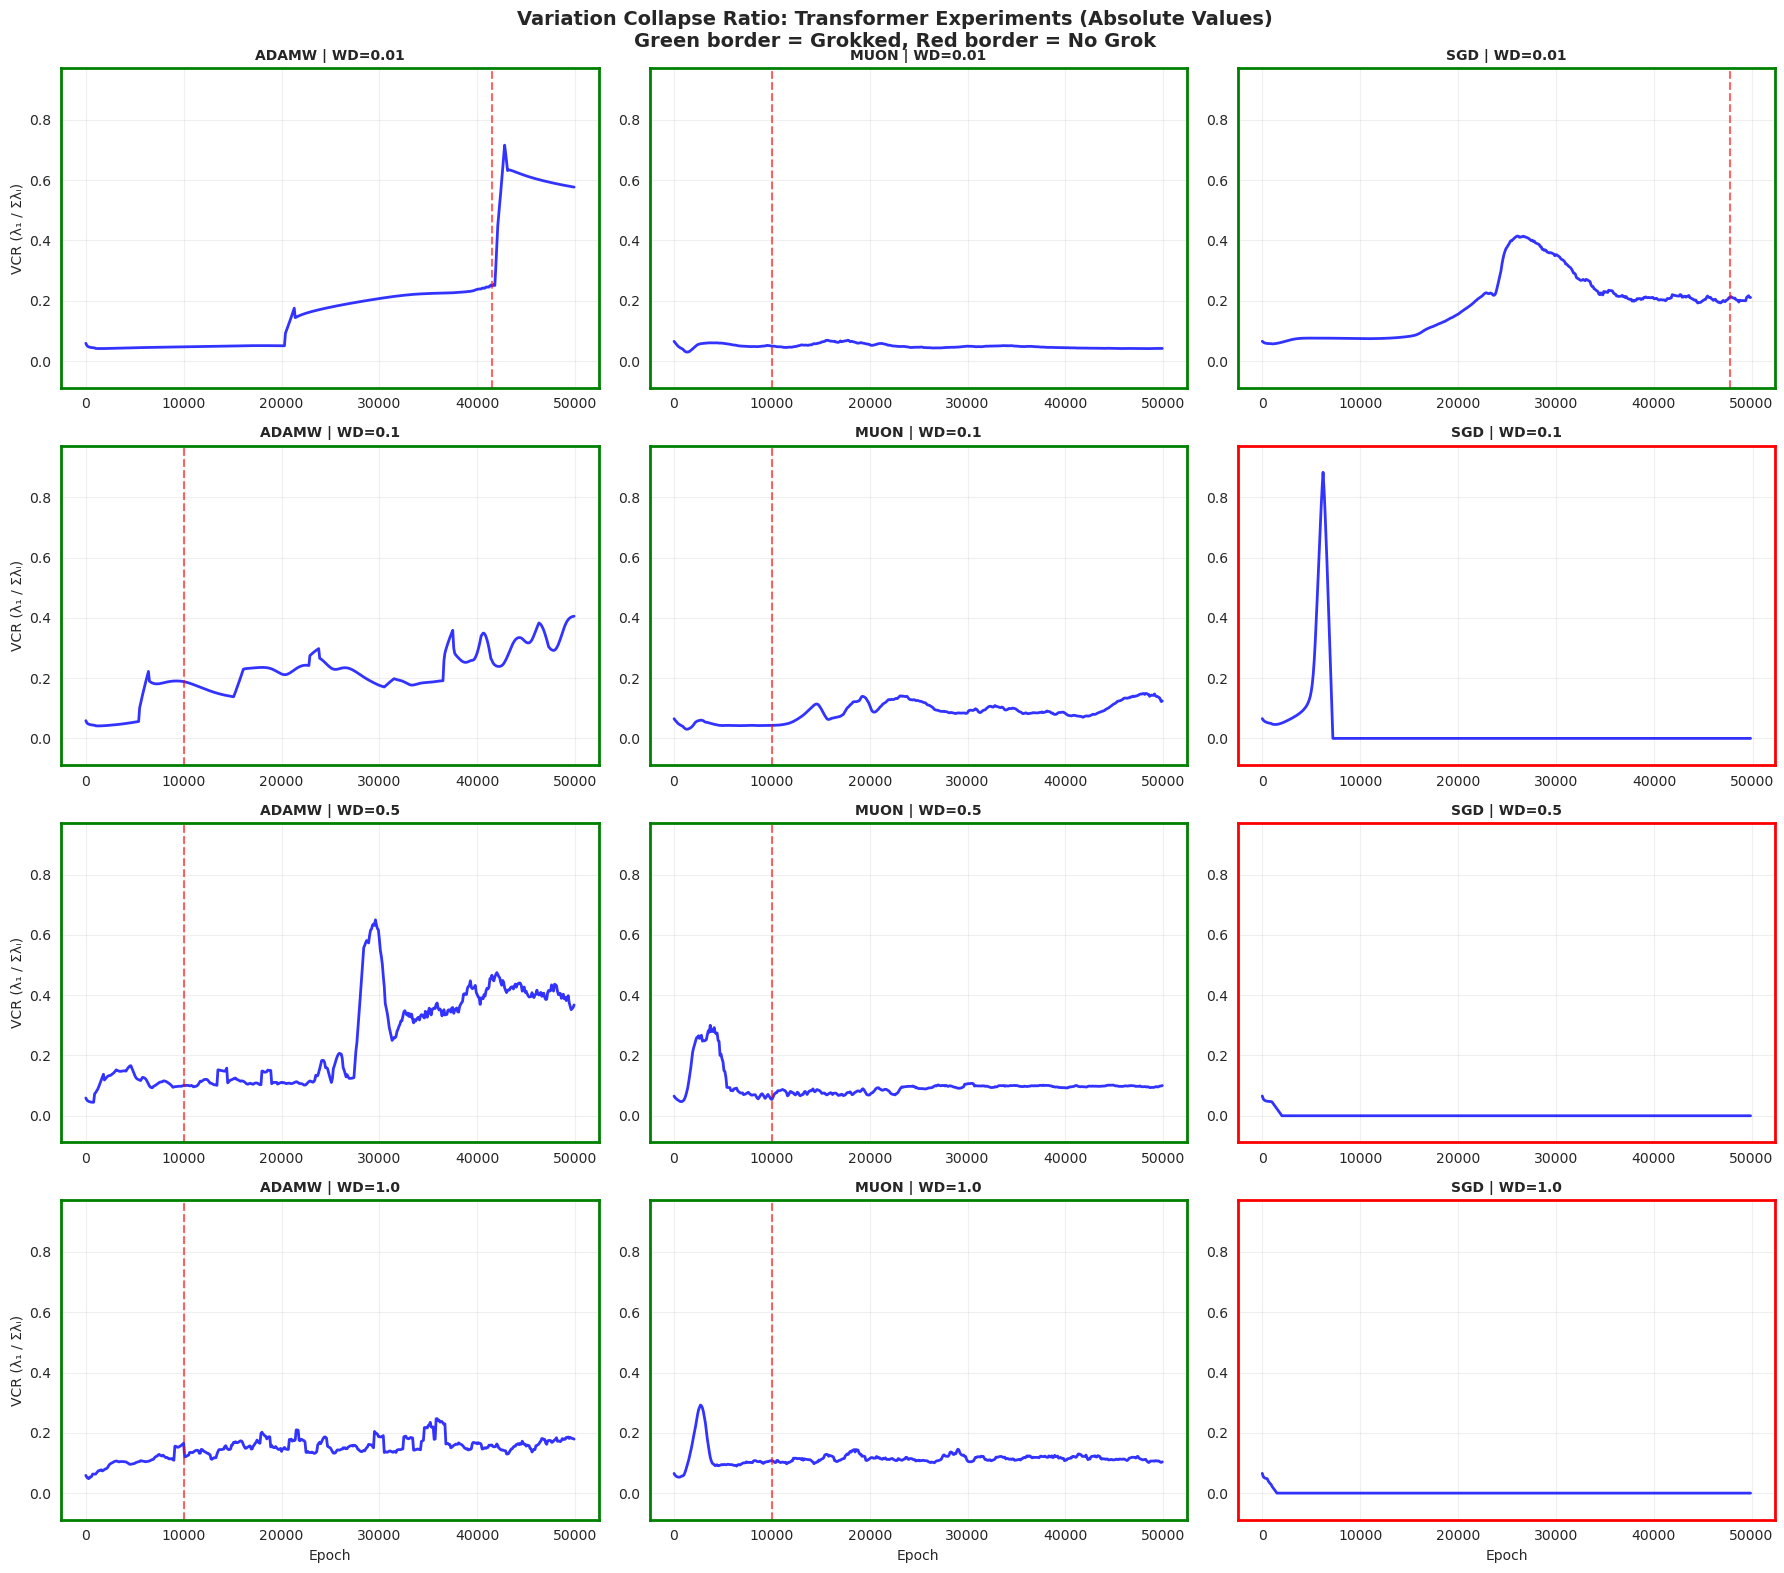

Generated: softmax_transformer_agop_variation_collapse_ratio_absolute.png


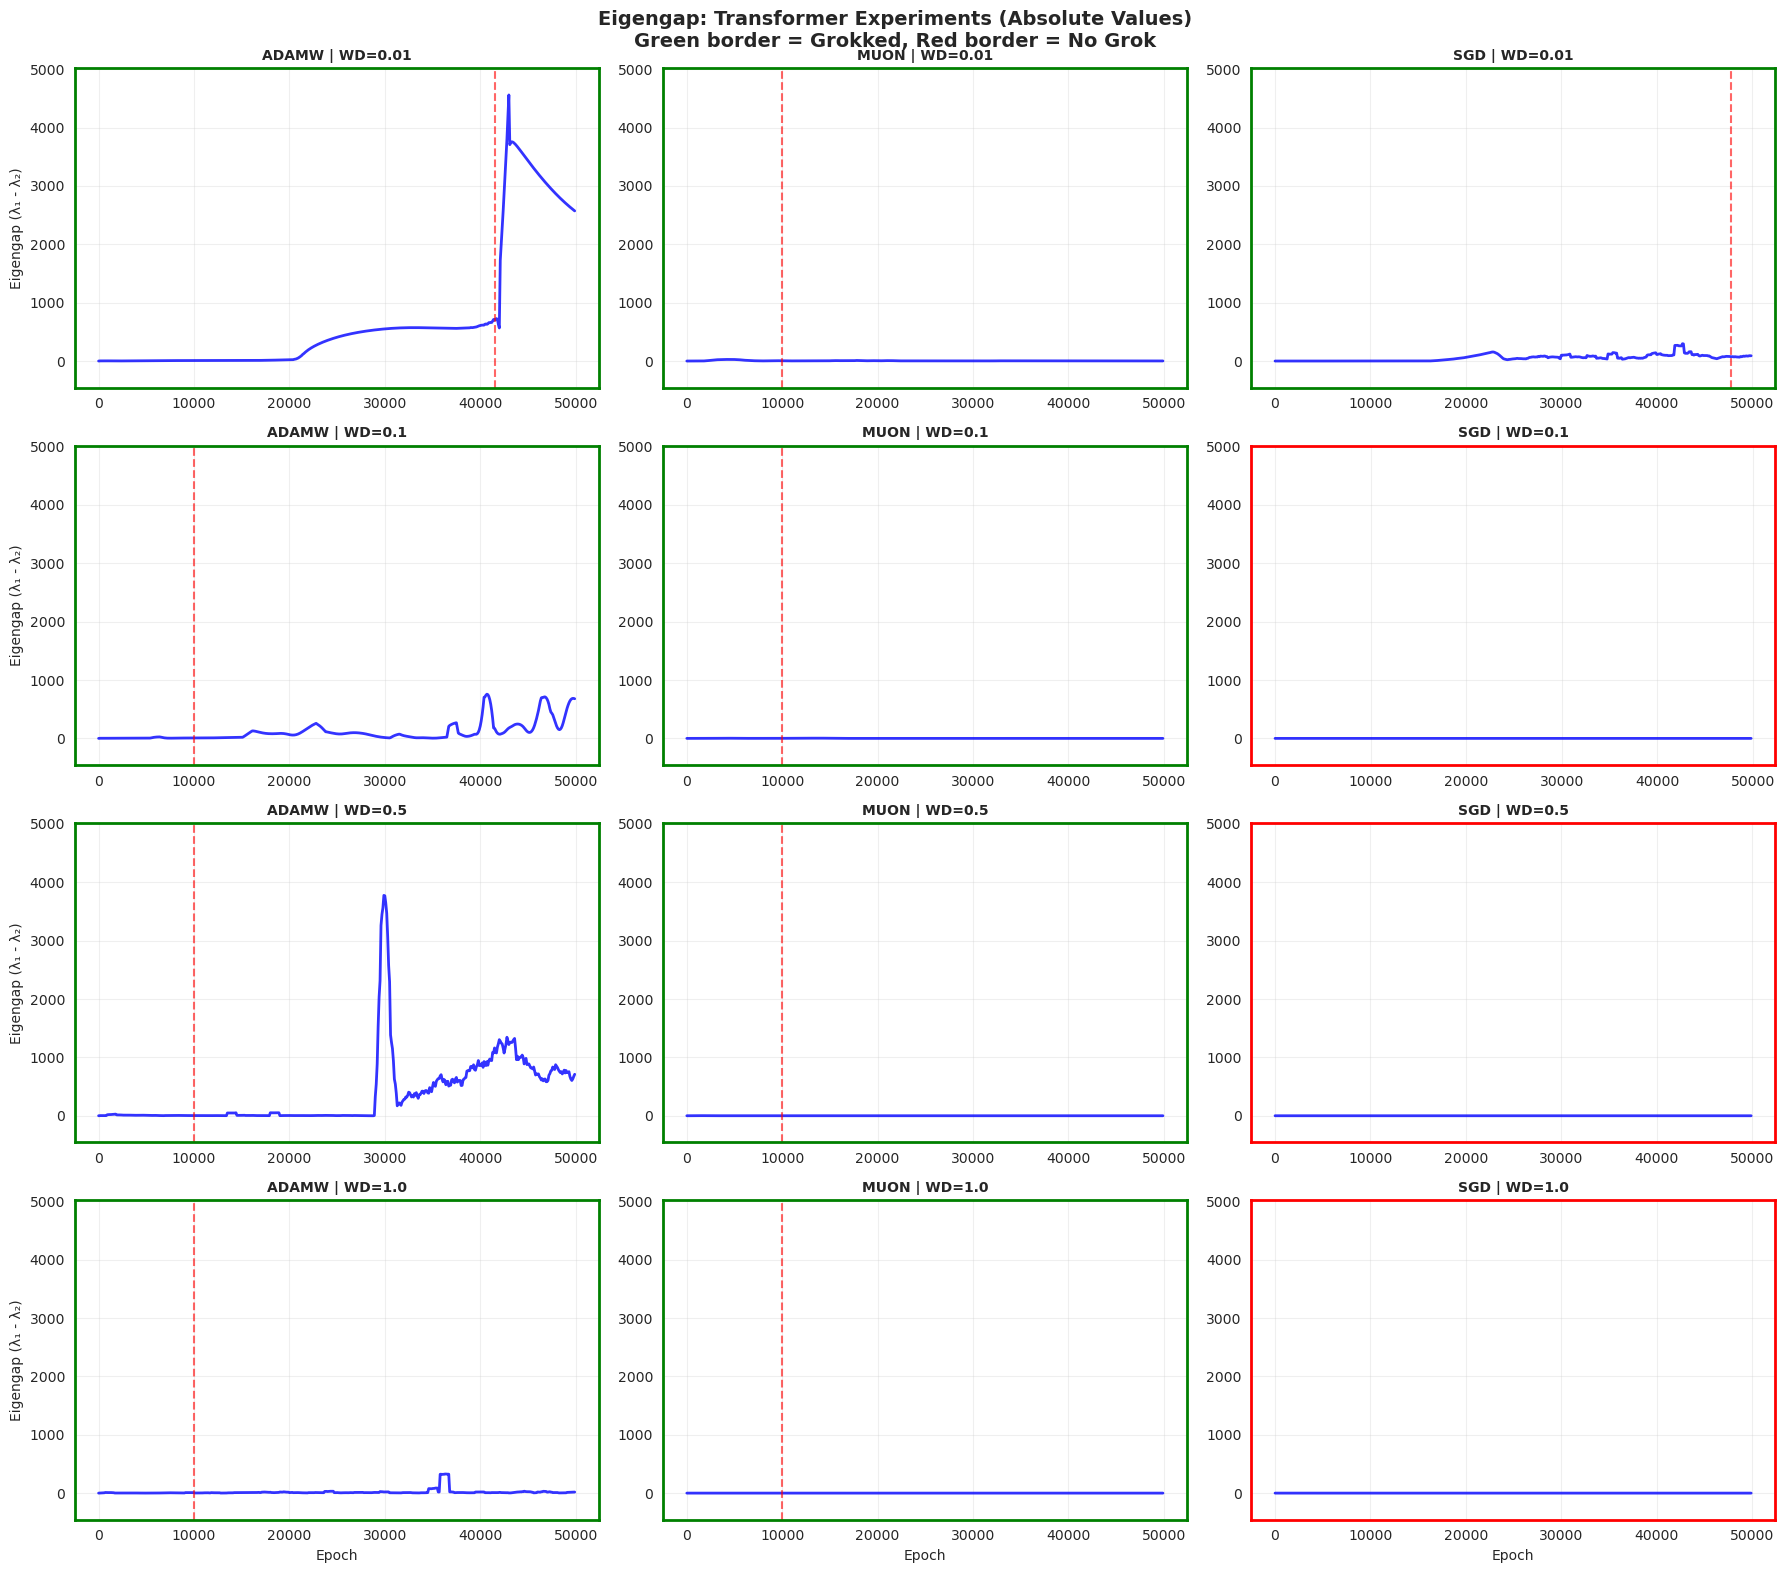

Generated: softmax_transformer_agop_eigengap_absolute.png


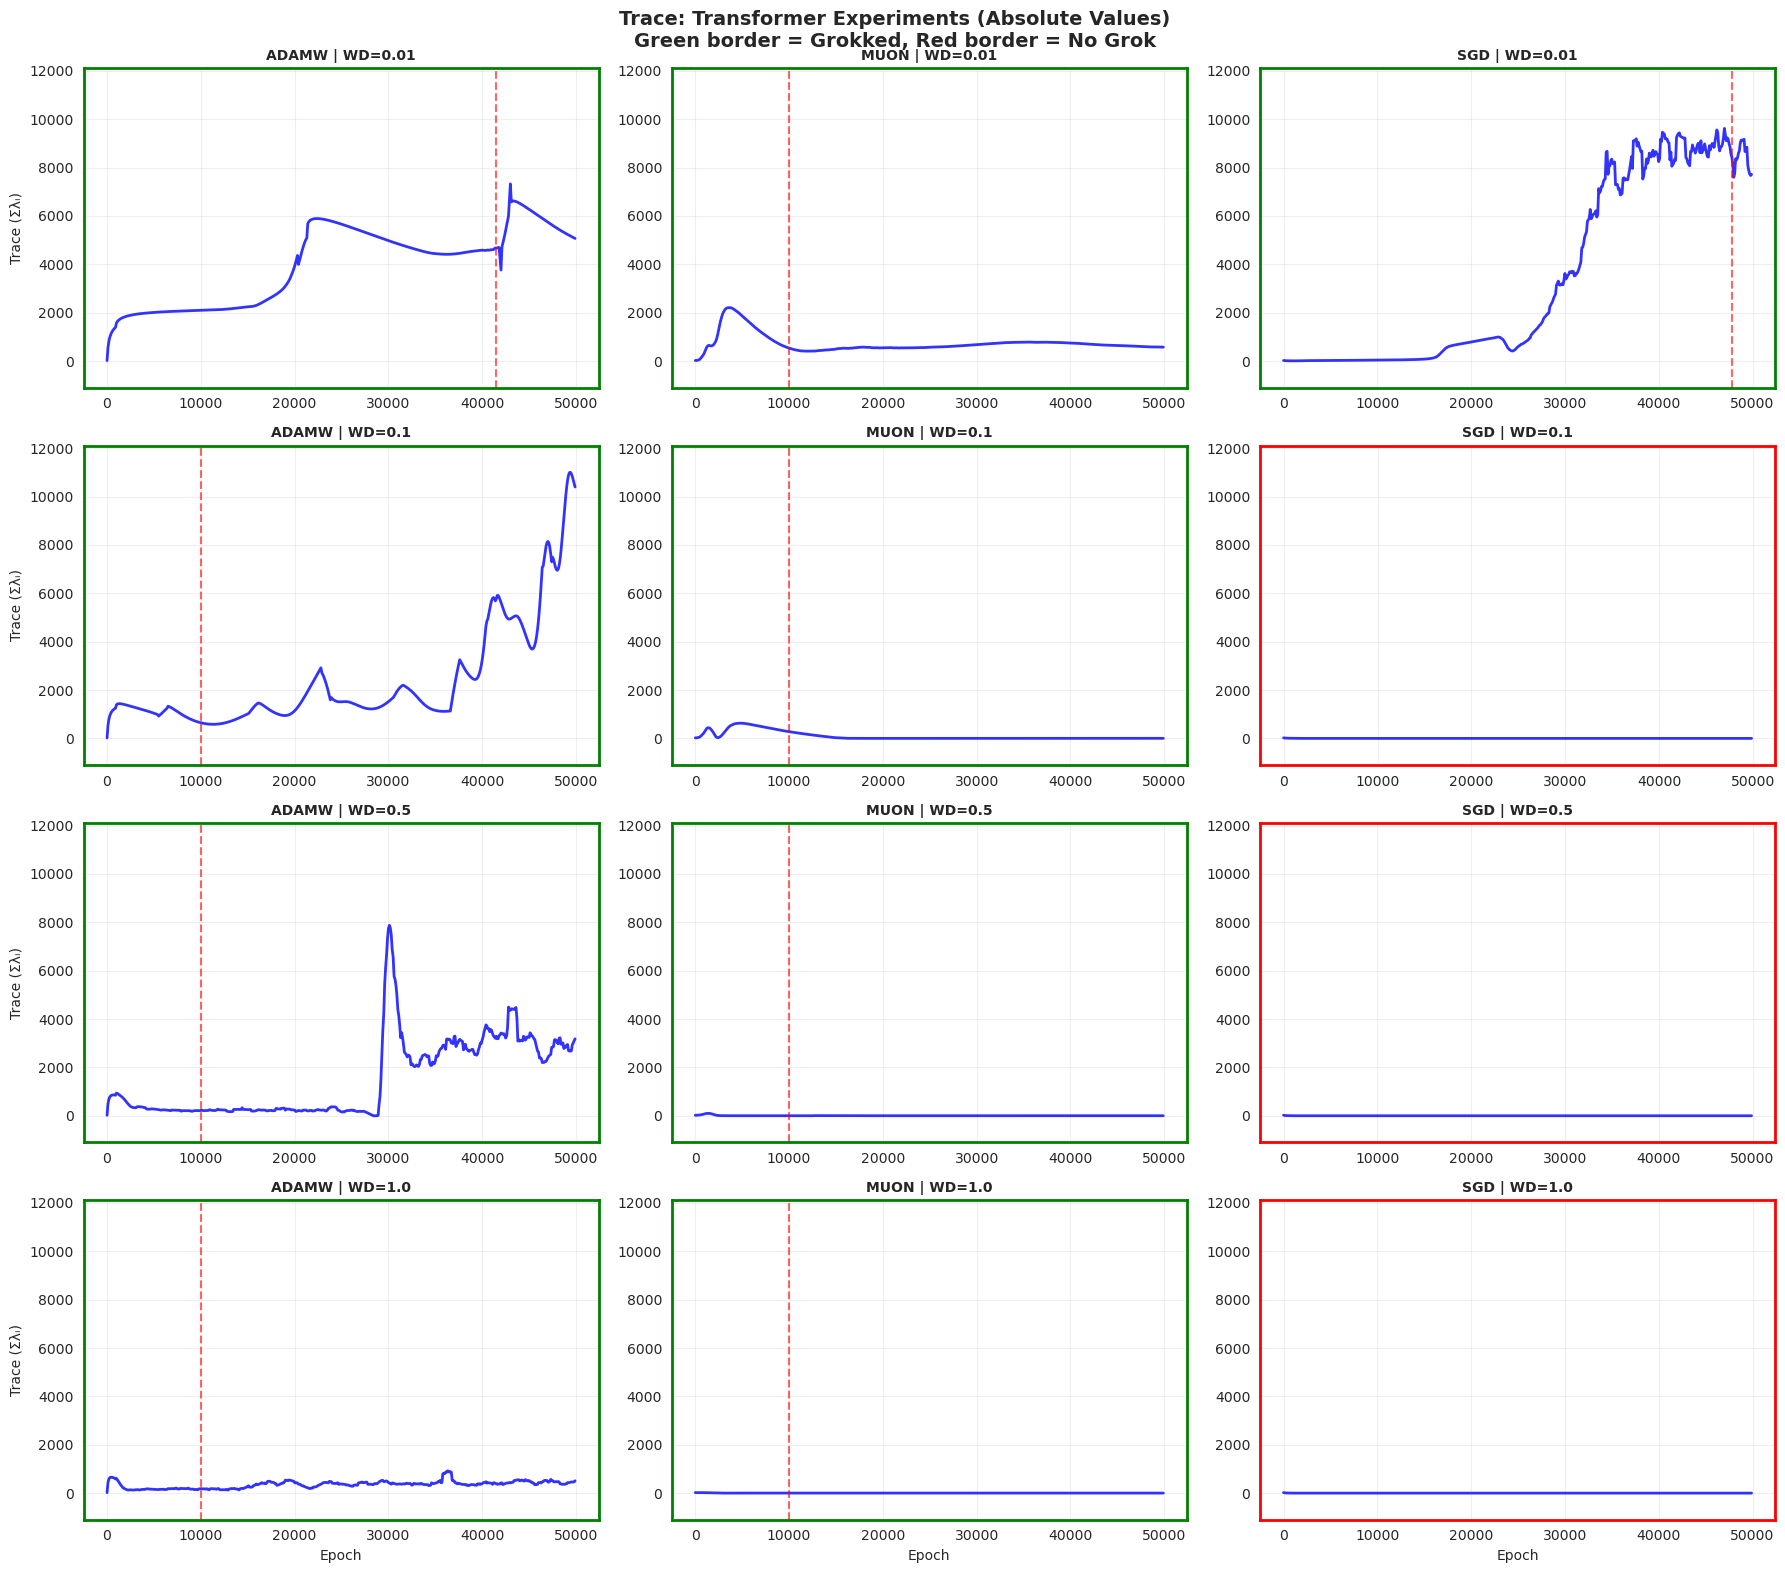

Generated: softmax_transformer_agop_trace_absolute.png


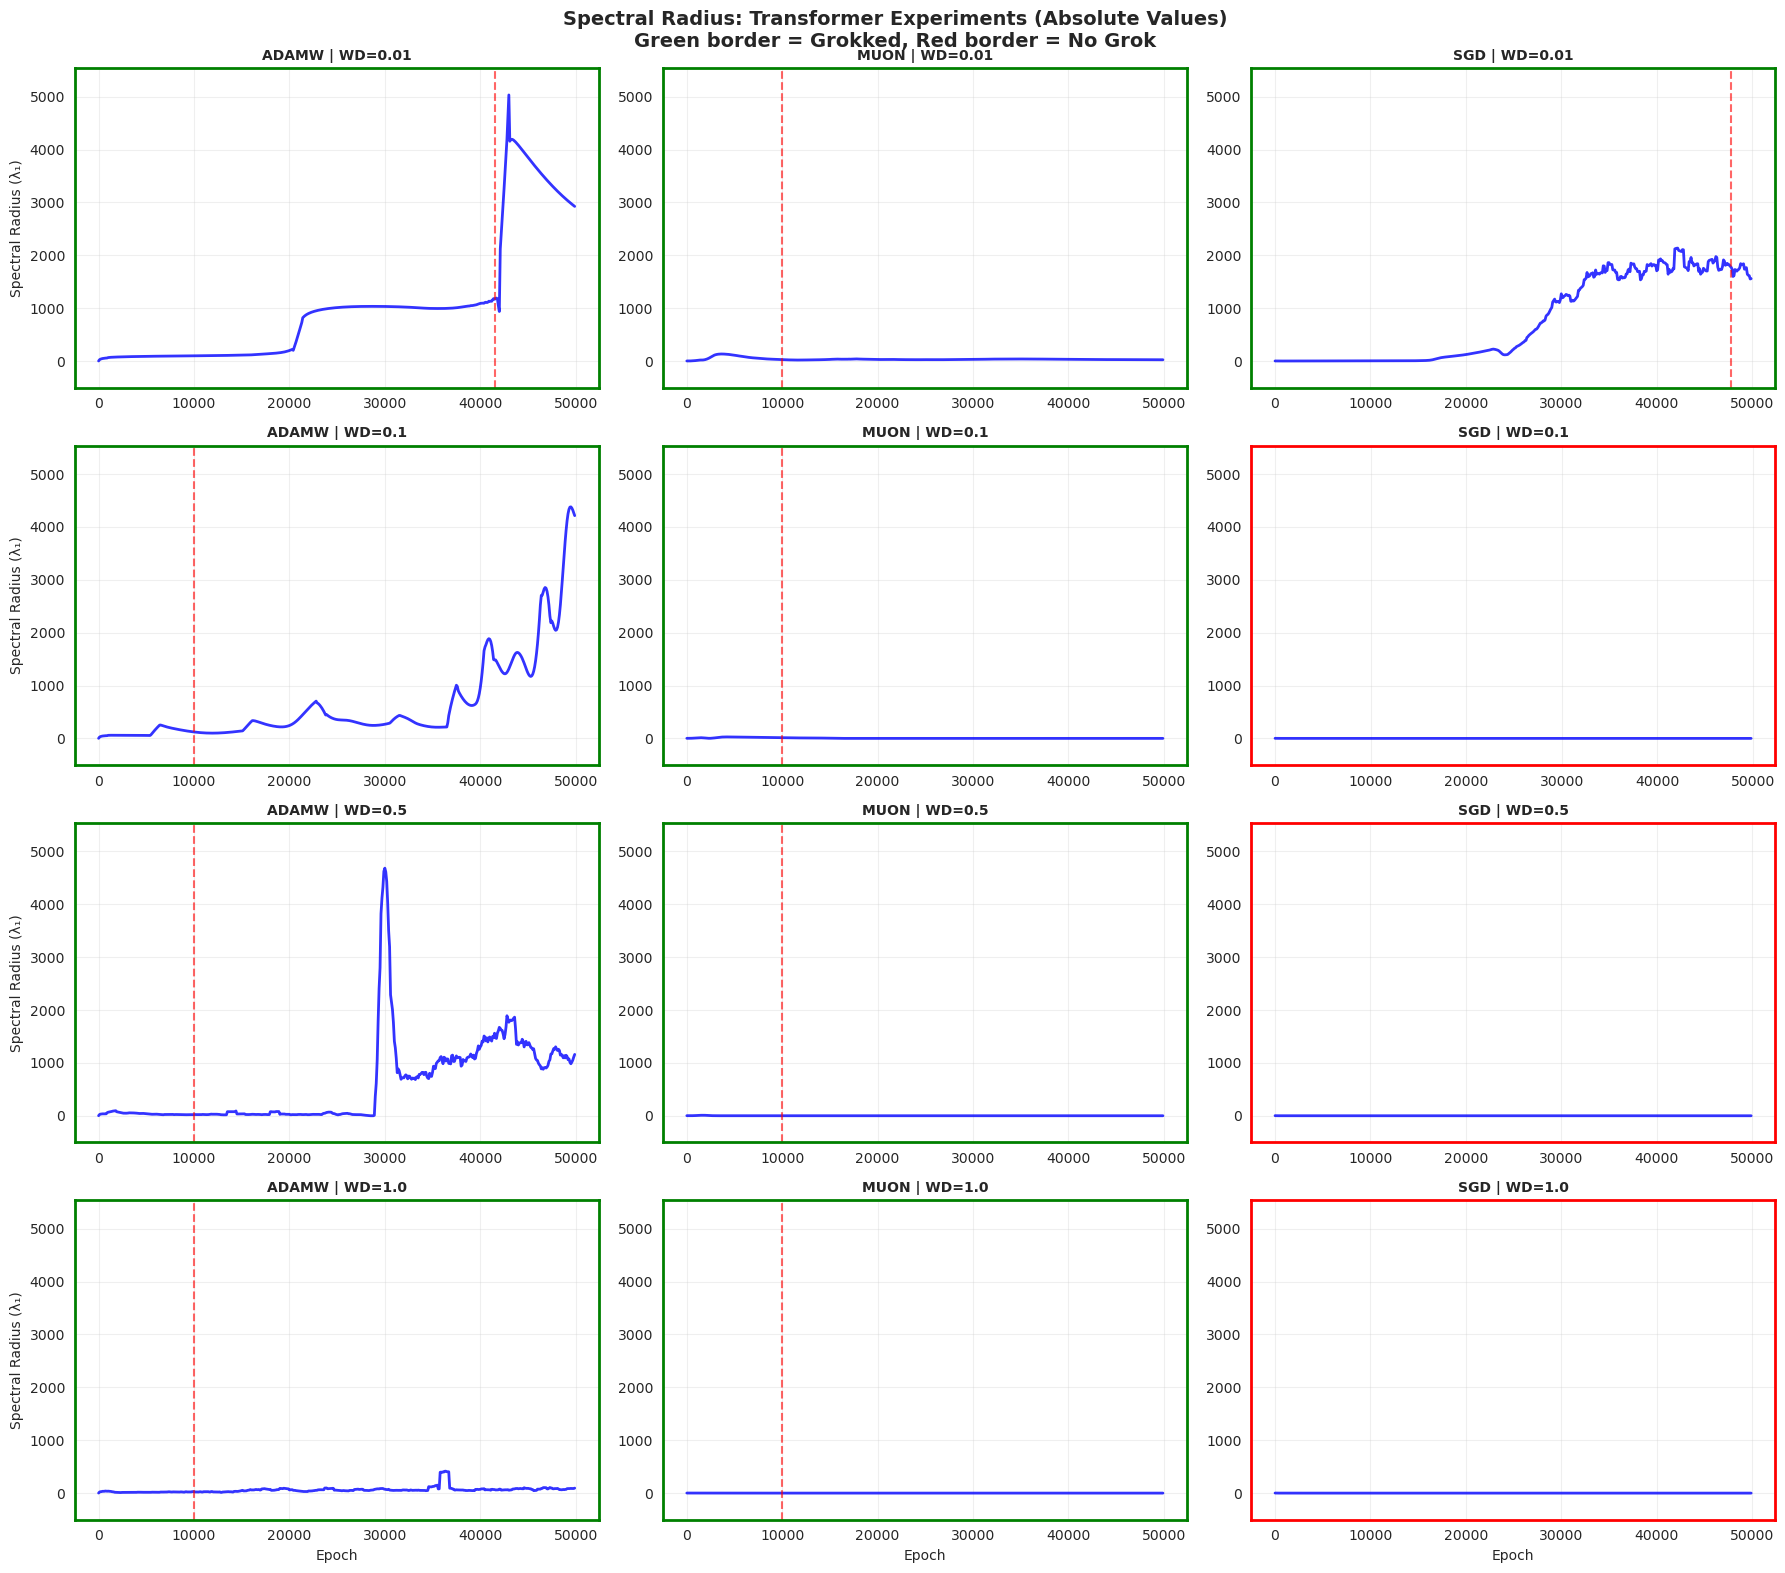

Generated: softmax_transformer_agop_spectral_radius_absolute.png

Section B complete: 4 absolute AGOP metric figures generated


In [ ]:
# Create overview plot with all experiments
n_experiments = len(experiments)
n_cols = 3
n_rows = int(np.ceil(n_experiments / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

exp_list = list(experiments.items())
exp_list.sort(key=lambda x: (x[1]['config'].get('optimizer', ''), x[1]['config'].get('weight_decay', 0)))

for idx, (exp_name, exp_data) in enumerate(exp_list):
    ax = axes[idx]
    history = exp_data.get('history', {})
    config = exp_data.get('config', {})
    
    if 'test_acc' not in history or 'train_acc' not in history:
        ax.axis('off')
        continue
    
    epochs = np.array(history.get('epoch', range(len(history['test_acc']))))
    train_acc = np.array(history['train_acc'])
    test_acc = np.array(history['test_acc'])
    
    # Detect grokking
    grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
    grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
    
    # Plot
    ax.plot(epochs, train_acc, 'b-', linewidth=1.5, label='Train', alpha=0.7)
    ax.plot(epochs, test_acc, 'orange', linewidth=1.5, label='Test', alpha=0.7)
    
    if grok_epoch is not None:
        ax.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2, alpha=0.7)
        ax.text(grok_epoch, 0.05, f'Epoch {grok_epoch}', 
               rotation=90, verticalalignment='bottom', fontsize=8, color='red',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    
    # Title
    opt = config.get('optimizer', 'unknown')
    wd = config.get('weight_decay', 0)
    status = "GROKKED ✓" if grok_epoch else "NO GROK"
    title_color = 'green' if grok_epoch else 'darkred'
    ax.set_title(f'{opt.upper()} | WD={wd}\n{status}', 
                fontsize=10, fontweight='bold', color=title_color)
    
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel('Accuracy', fontsize=9)
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

# Hide unused subplots
for idx in range(len(exp_list), len(axes)):
    axes[idx].axis('off')

fig.suptitle('Softmax Transformer Training Dynamics Overview: All Experiments', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'training_dynamics_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved overview figure: training_dynamics_overview.png")


## Focused Analysis: Grokking by Optimizer

Deep dive into configurations that achieve grokking.
We'll examine how different optimizers and weight decay settings affect the grokking phenomenon.


# Group experiments by optimizer
softmax_by_opt = {}
for opt in ['adamw', 'muon', 'sgd']:
    opt_exps = {name: data for name, data in experiments.items() 
                if data['config'].get('optimizer') == opt}
    if len(opt_exps) > 0:
        softmax_by_opt[opt] = sorted(opt_exps.items(), 
                                     key=lambda x: x[1]['config'].get('weight_decay', 0))

# Detailed breakdown by optimizer
for opt in ['adamw', 'muon', 'sgd']:
    if opt not in softmax_by_opt:
        continue
    
    sorted_exps = softmax_by_opt[opt]
    
    print(f"\n{opt.upper()} Softmax Transformer experiments: {len(sorted_exps)}")
    
    # Count grokking
    grok_count = sum(1 for _, data in sorted_exps 
                     if classify_grokking(data))
    print(f"  Grokked: {grok_count}/{len(sorted_exps)}")
    
    for exp_name, exp_data in sorted_exps:
        wd = exp_data['config'].get('weight_decay', 0)
        history = exp_data['history']
        
        if 'test_acc' not in history:
            continue
        
        test_acc = np.array(history['test_acc'])
        train_acc = np.array(history['train_acc'])
        
        grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
        epochs = np.array(history.get('epoch', range(len(test_acc))))
        grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
        
        final_test = test_acc[-1]
        final_train = train_acc[-1]
        
        if grok_epoch:
            print(f"  WD={wd:5.2f}: GROKKED at epoch {grok_epoch:5d} | Final train/test: {final_train:.4f}/{final_test:.4f}")
        else:
            print(f"  WD={wd:5.2f}: NO GROK                  | Final train/test: {final_train:.4f}/{final_test:.4f}")


Generating normalized AGOP + accuracy overlay plots...



NameError: name 'normalize_series' is not defined

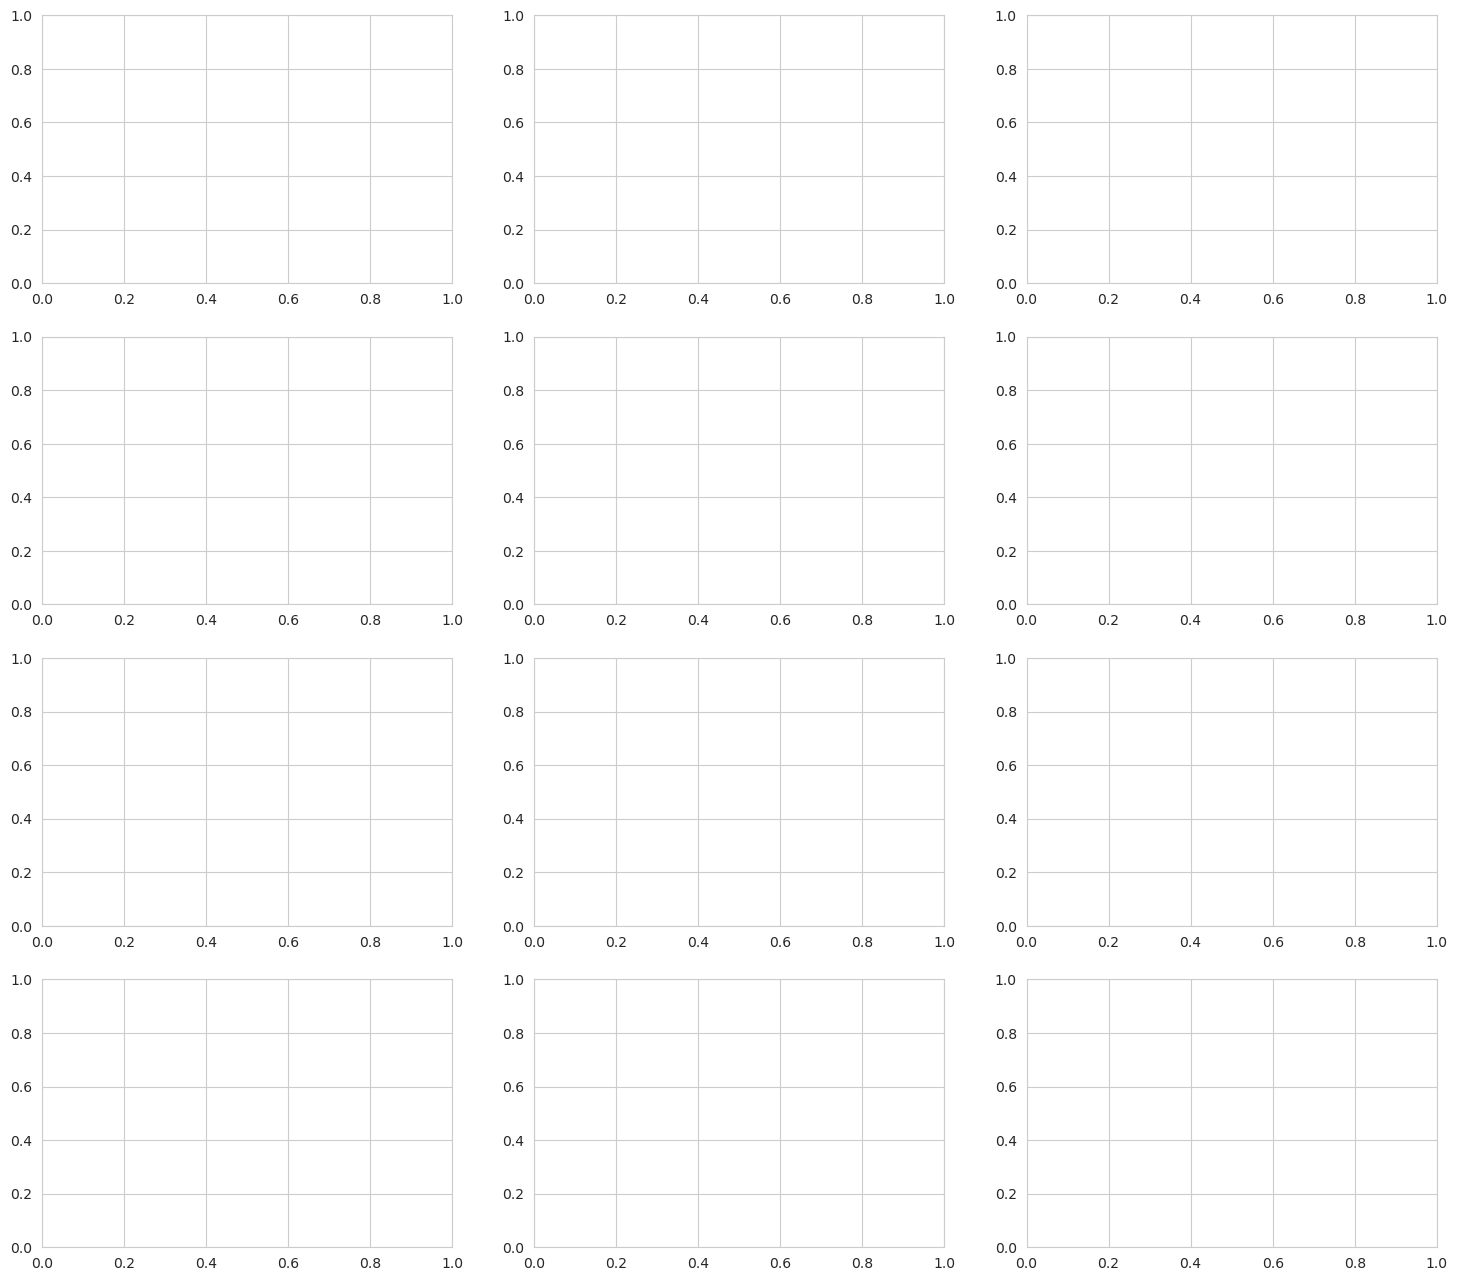

In [ ]:
---
# Section 1: AGOP Metrics Analysis

Now let's examine how AGOP metrics evolve differently across optimizers.
We'll compare configurations that grok vs those that don't with **normalized overlay plots**.


---
# Summary

The reorganized analysis focuses on Transformer experiments and provides clear visual comparisons across optimizers and weight decays.


Analyzing AGOP metrics for Transformer experiments by optimizer


Processing ADAMW Transformer experiments...


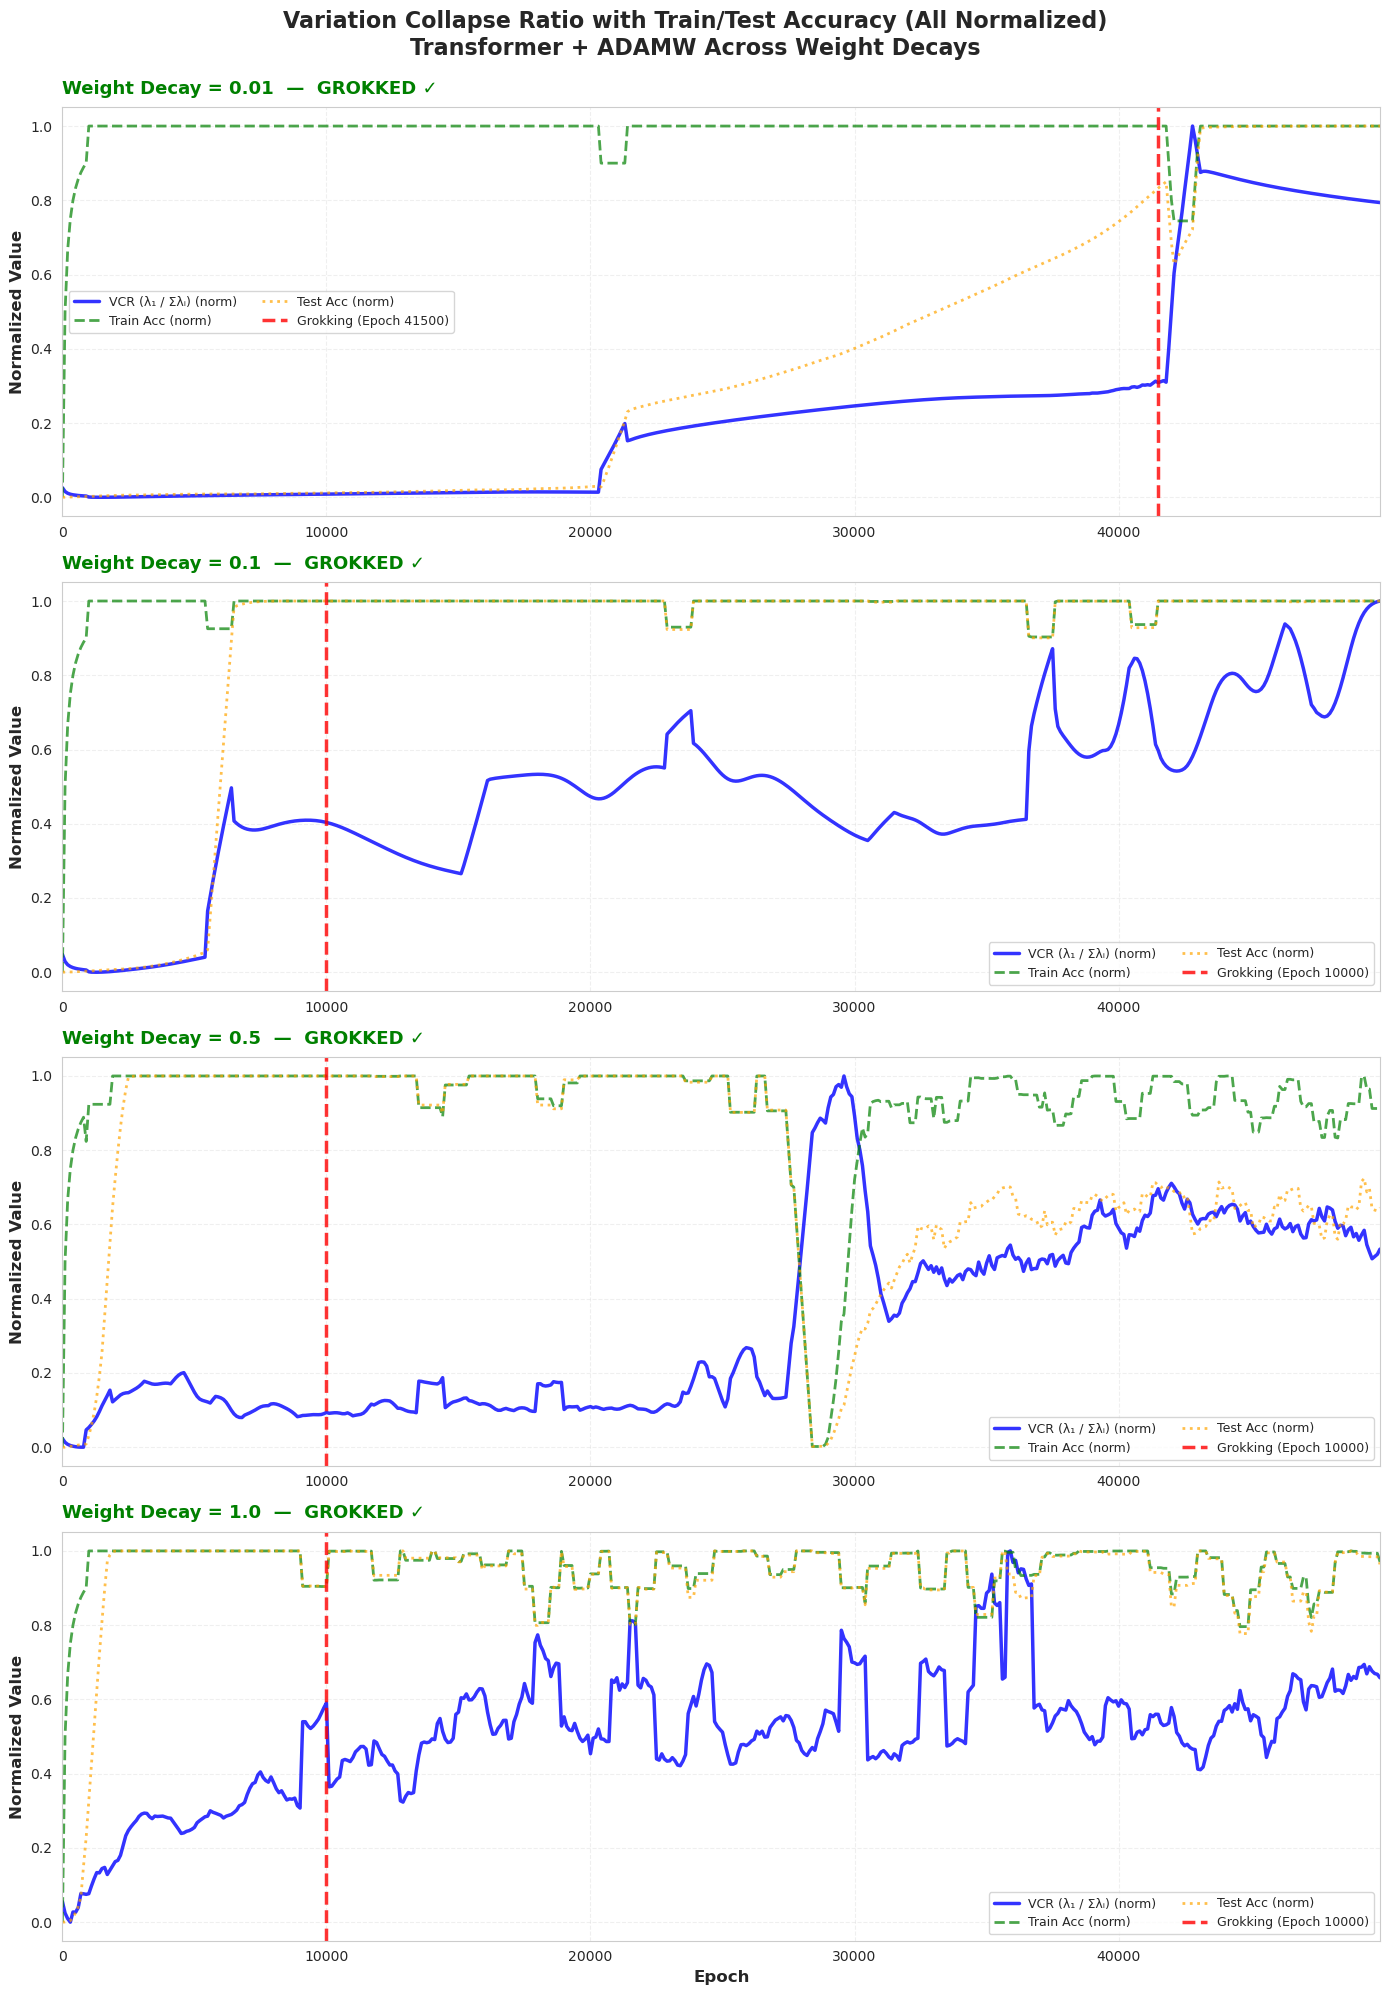

  Generated overlay panel for Variation Collapse Ratio


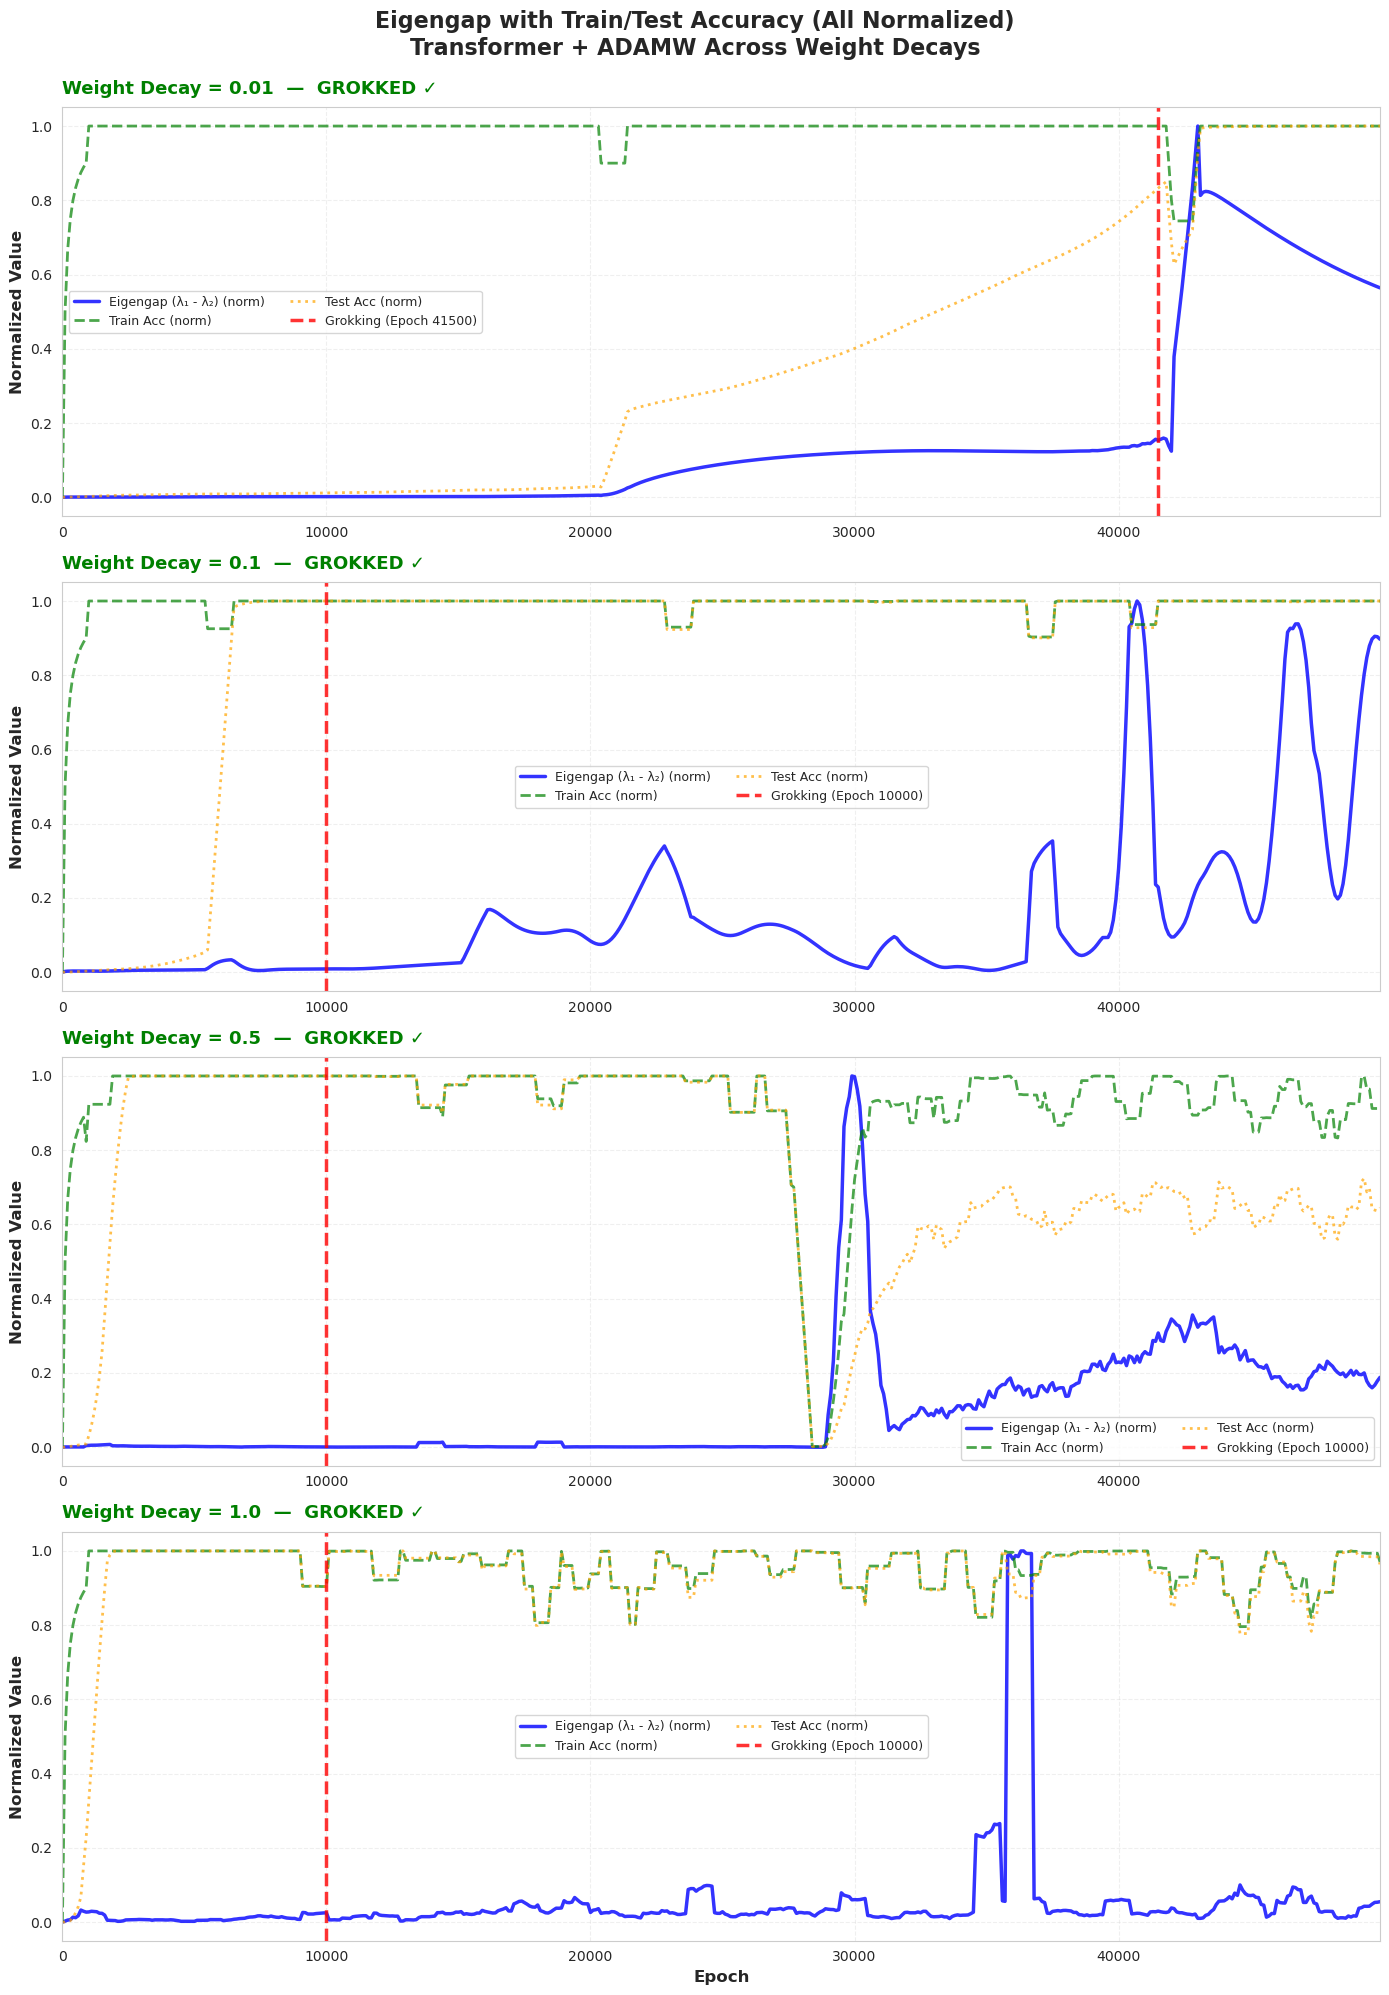

  Generated overlay panel for Eigengap


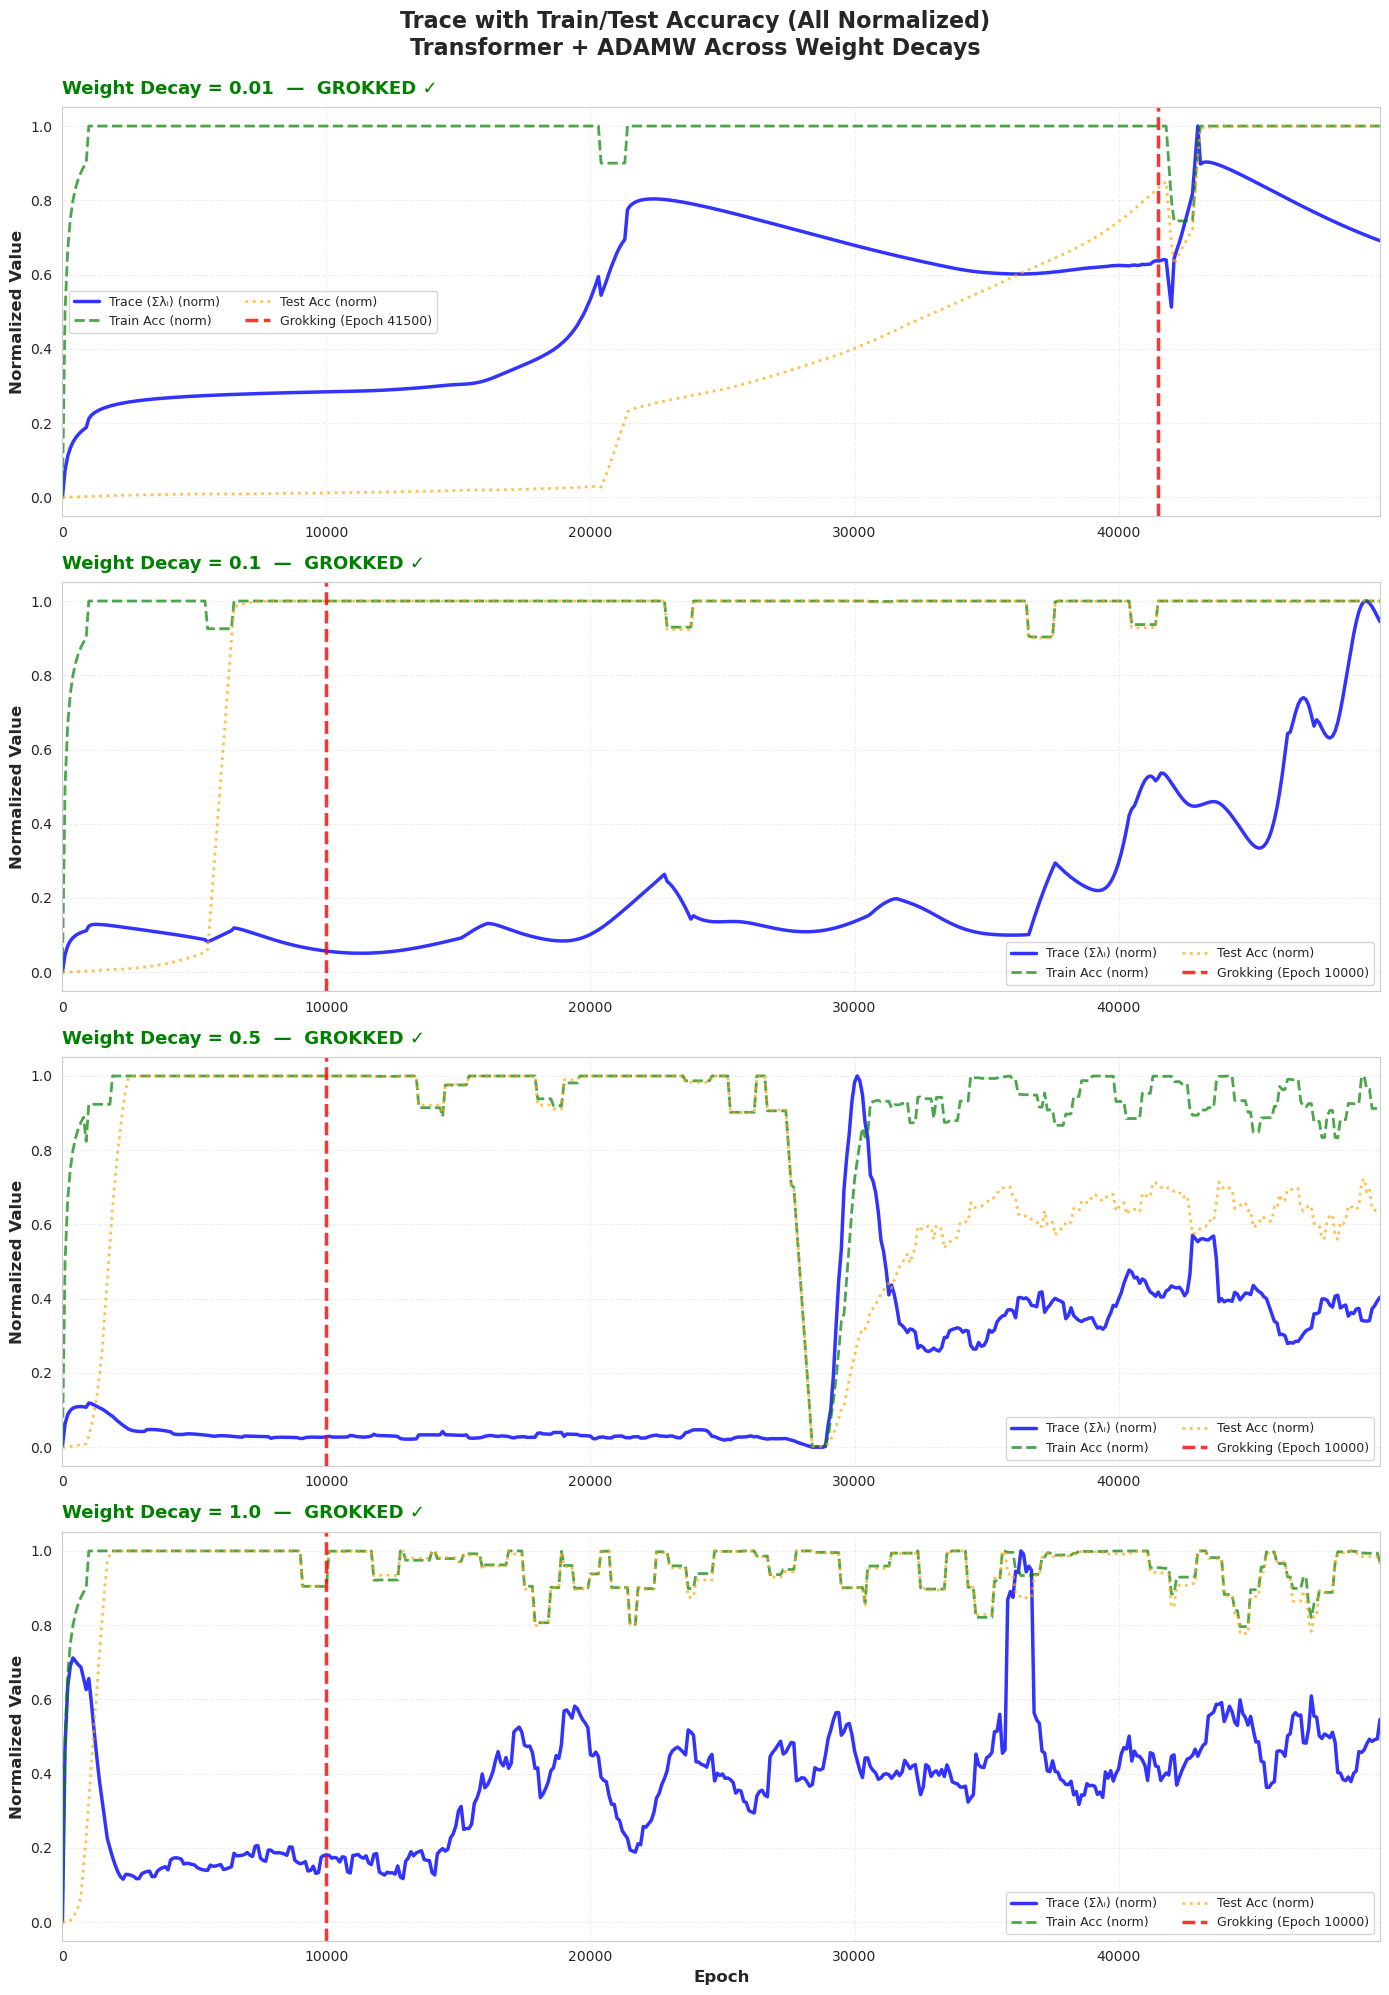

  Generated overlay panel for Trace


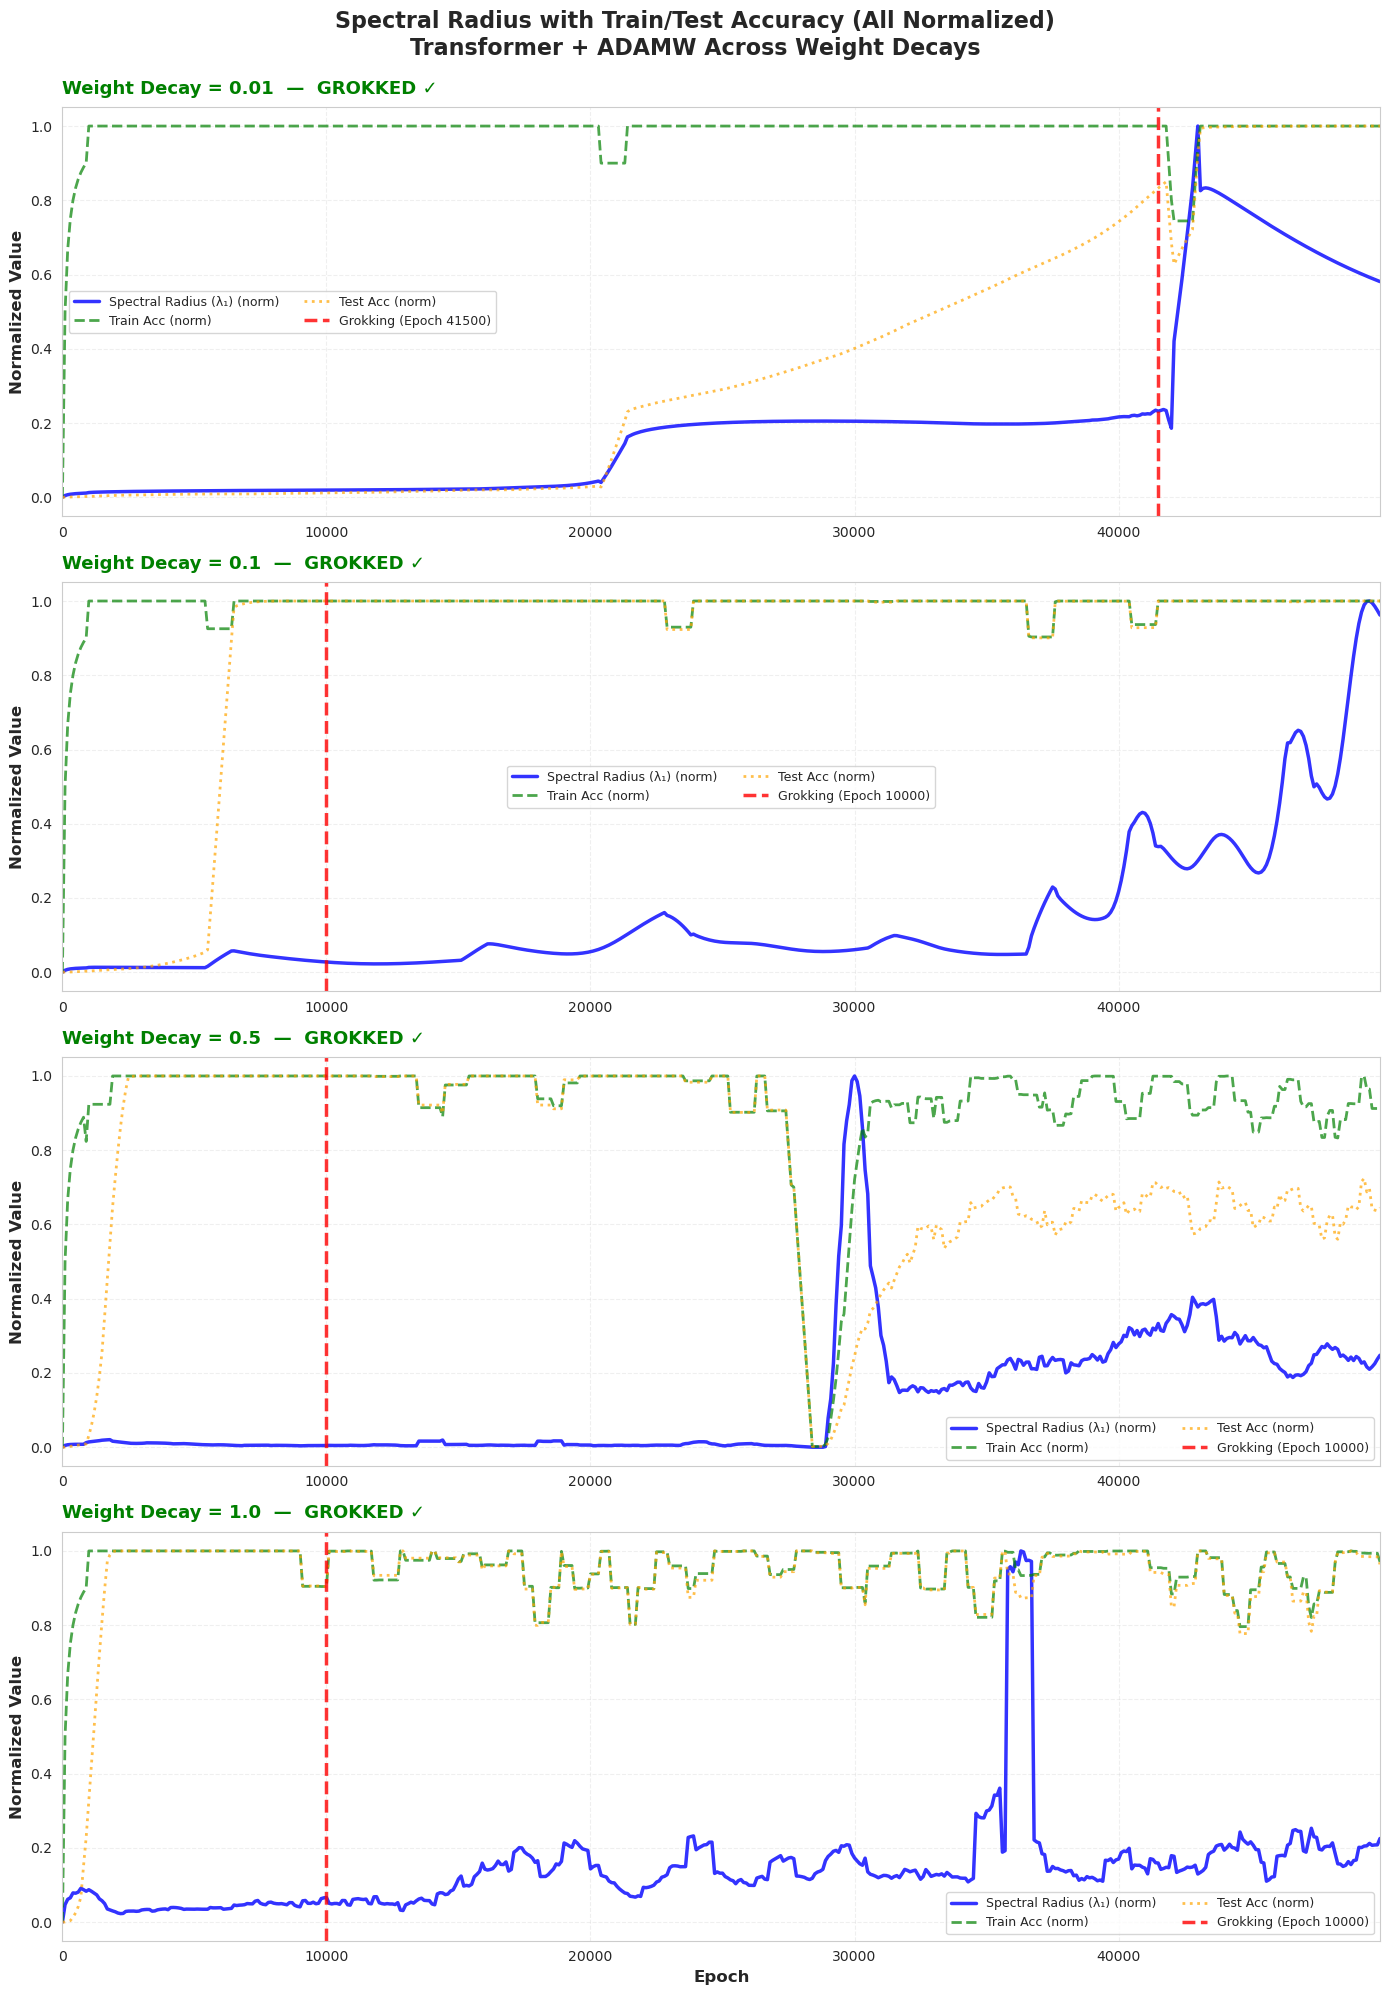

  Generated overlay panel for Spectral Radius

Processing MUON Transformer experiments...


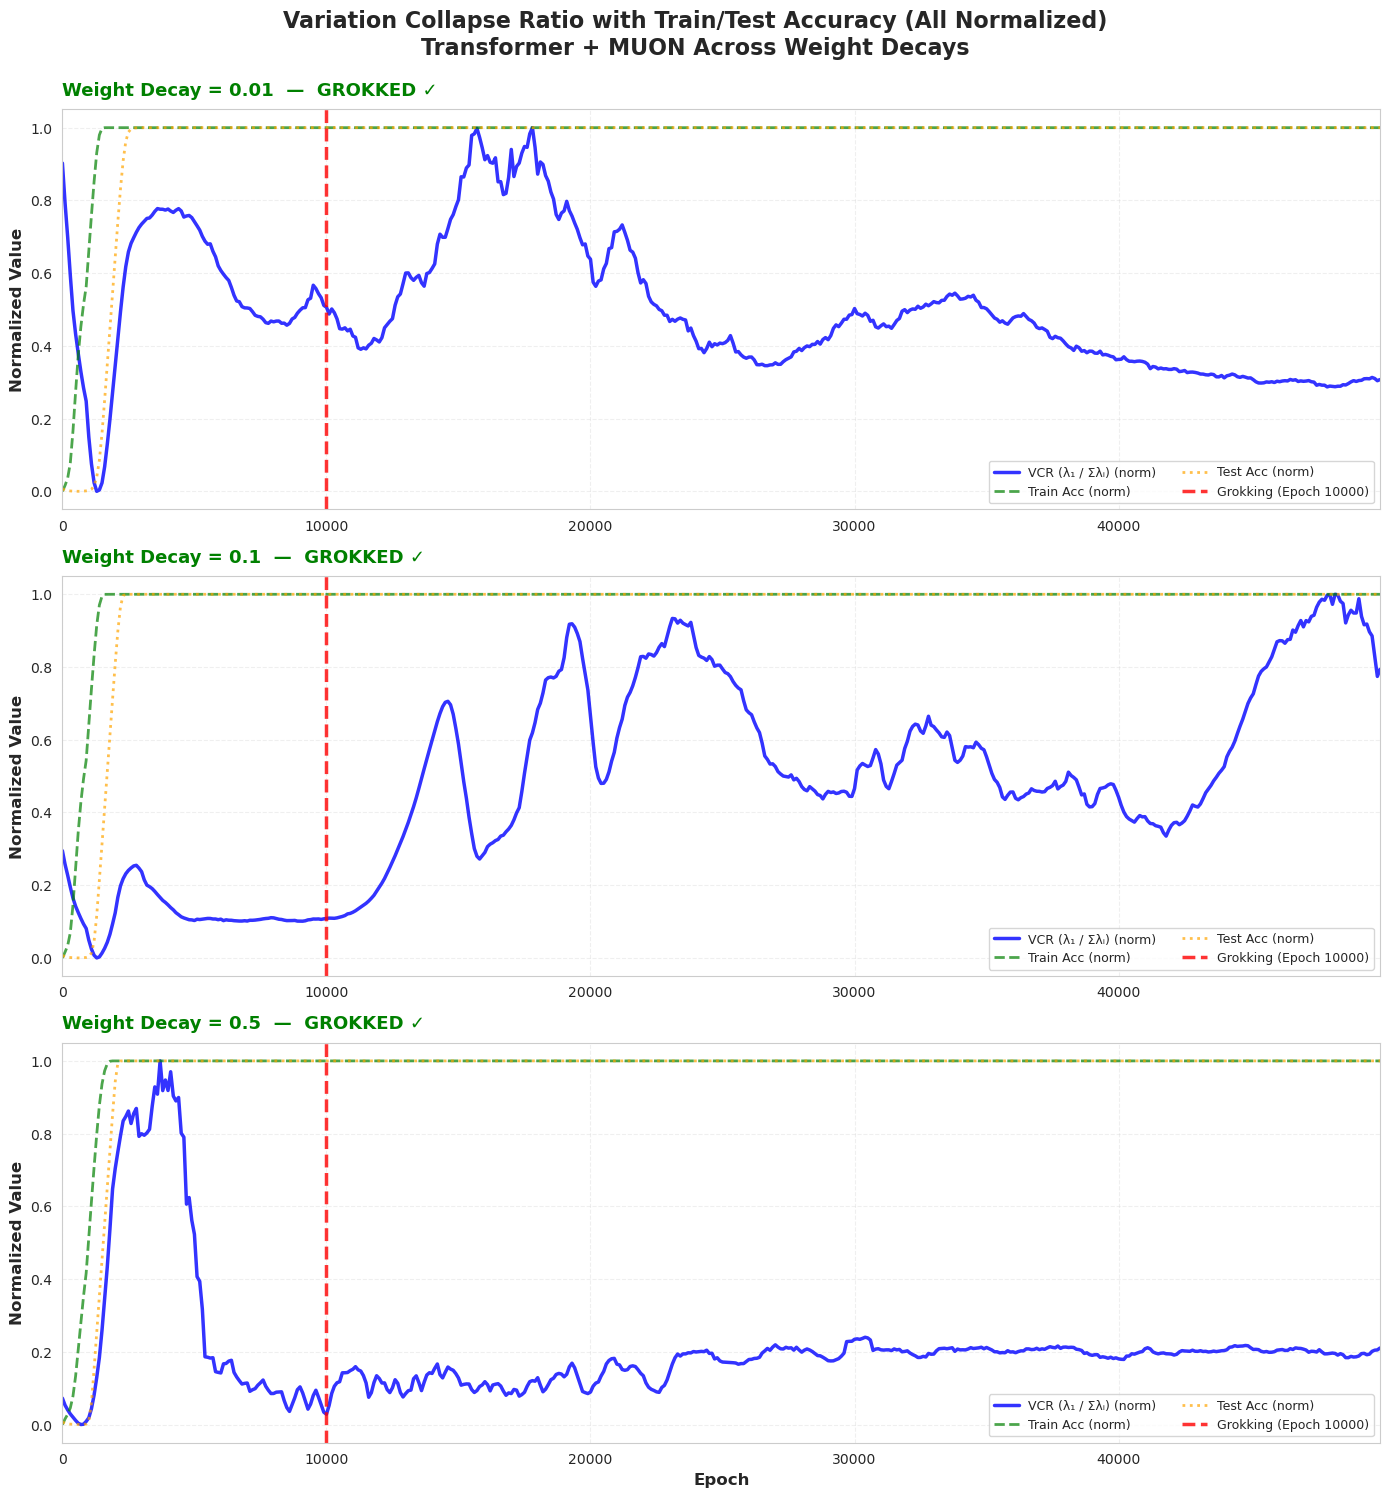

  Generated overlay panel for Variation Collapse Ratio


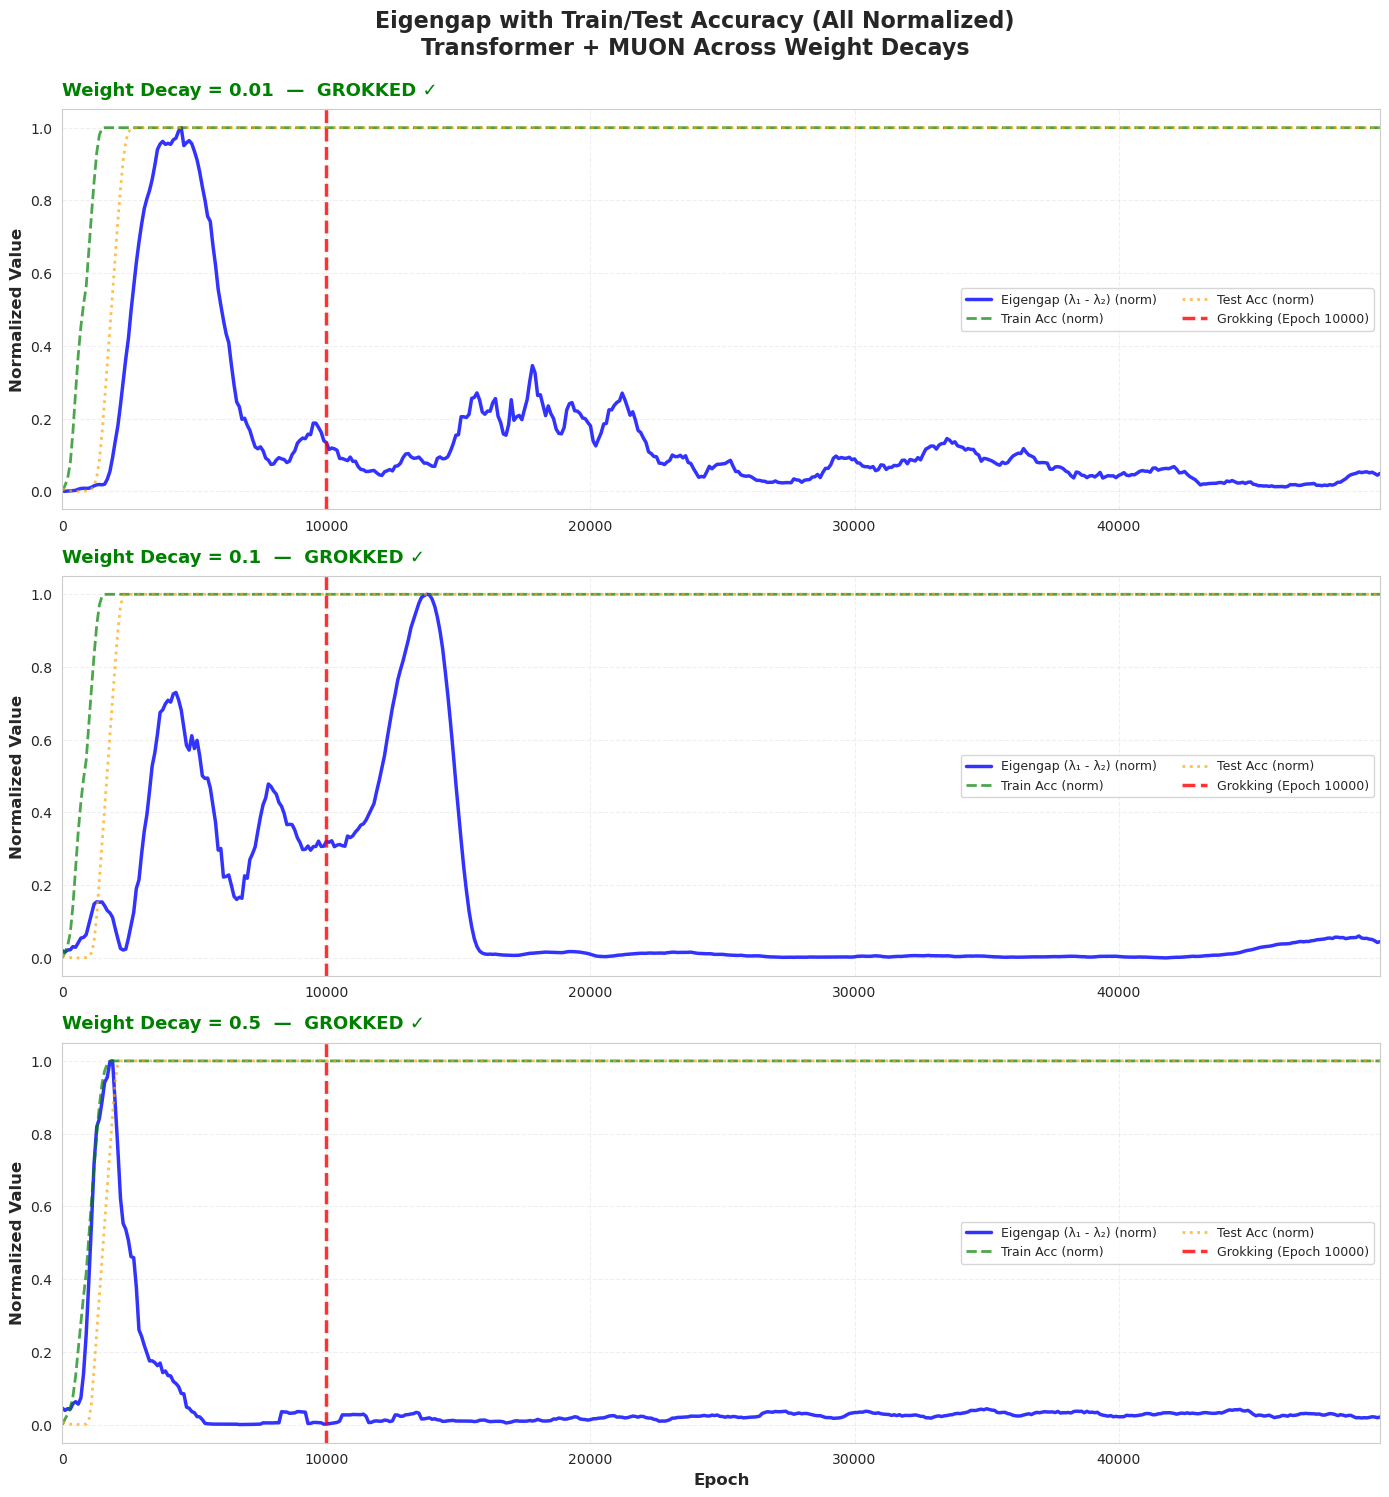

  Generated overlay panel for Eigengap


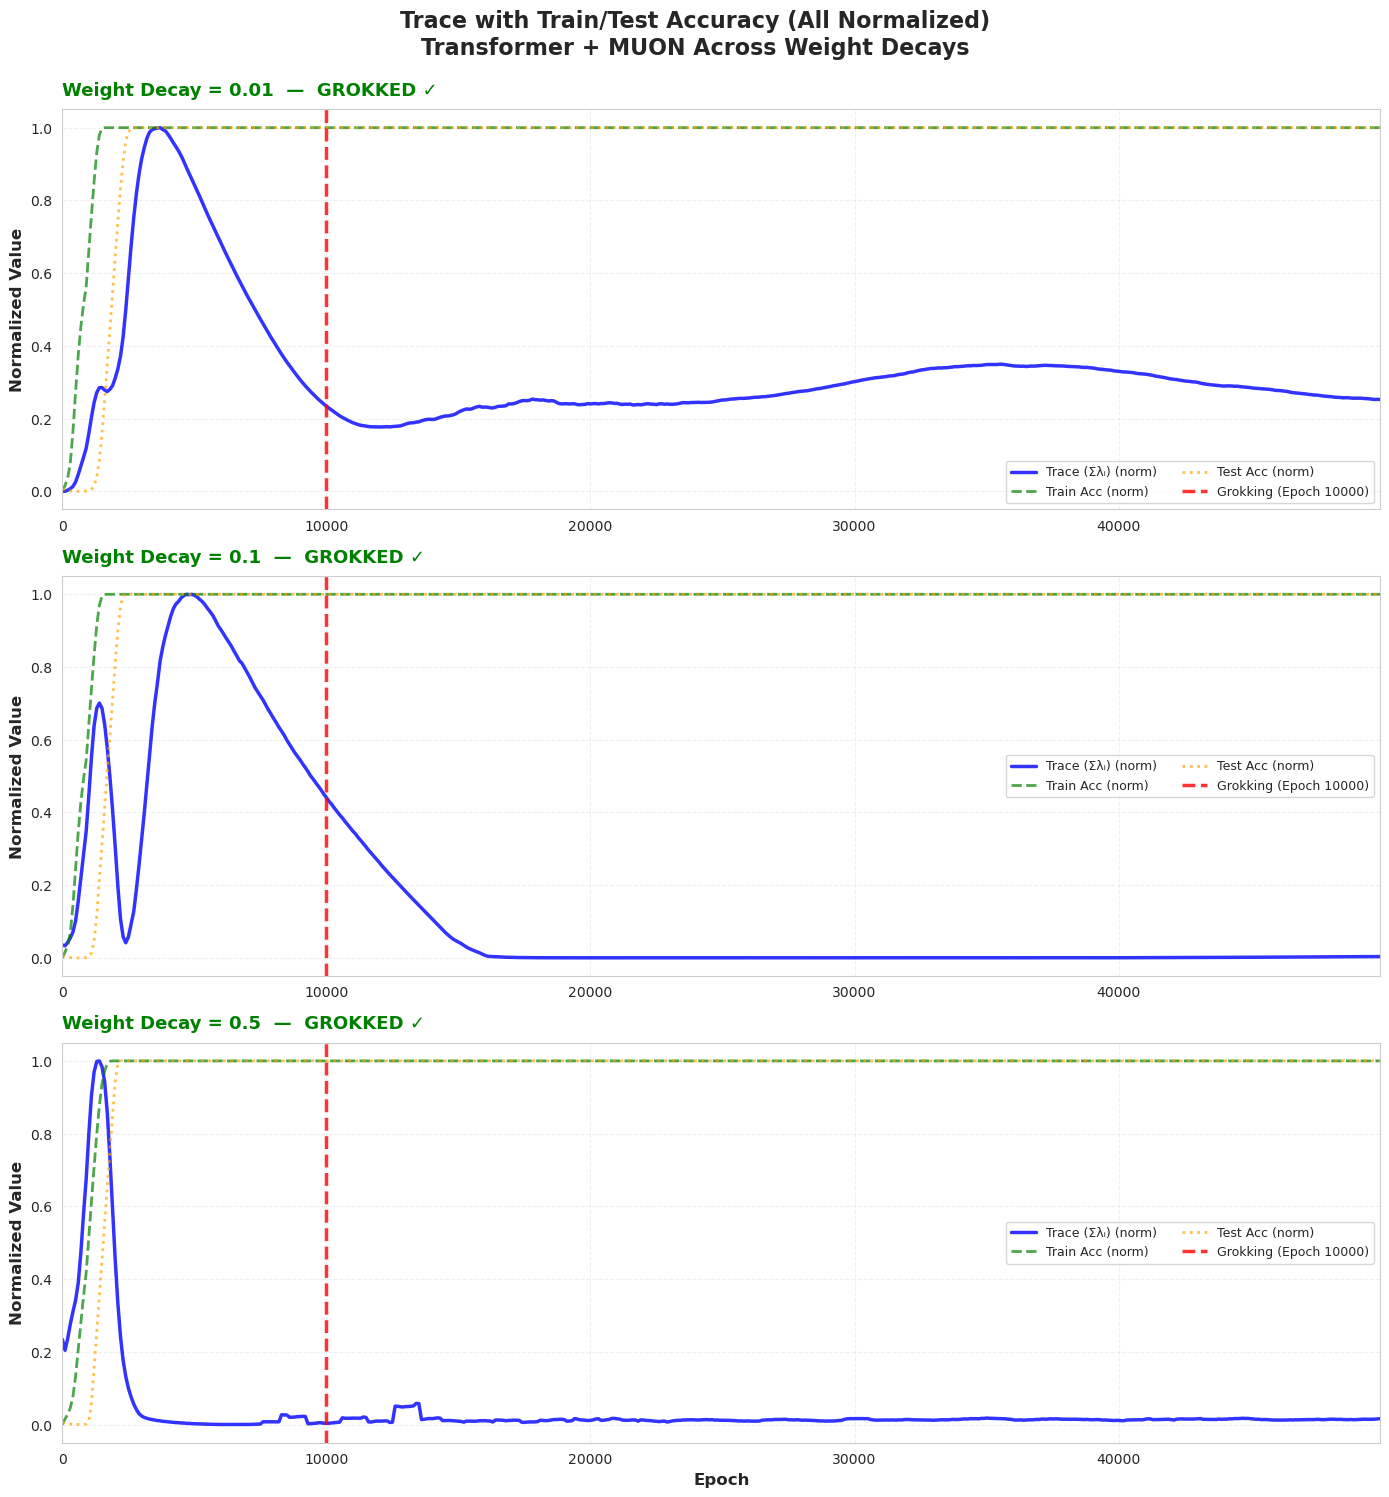

  Generated overlay panel for Trace


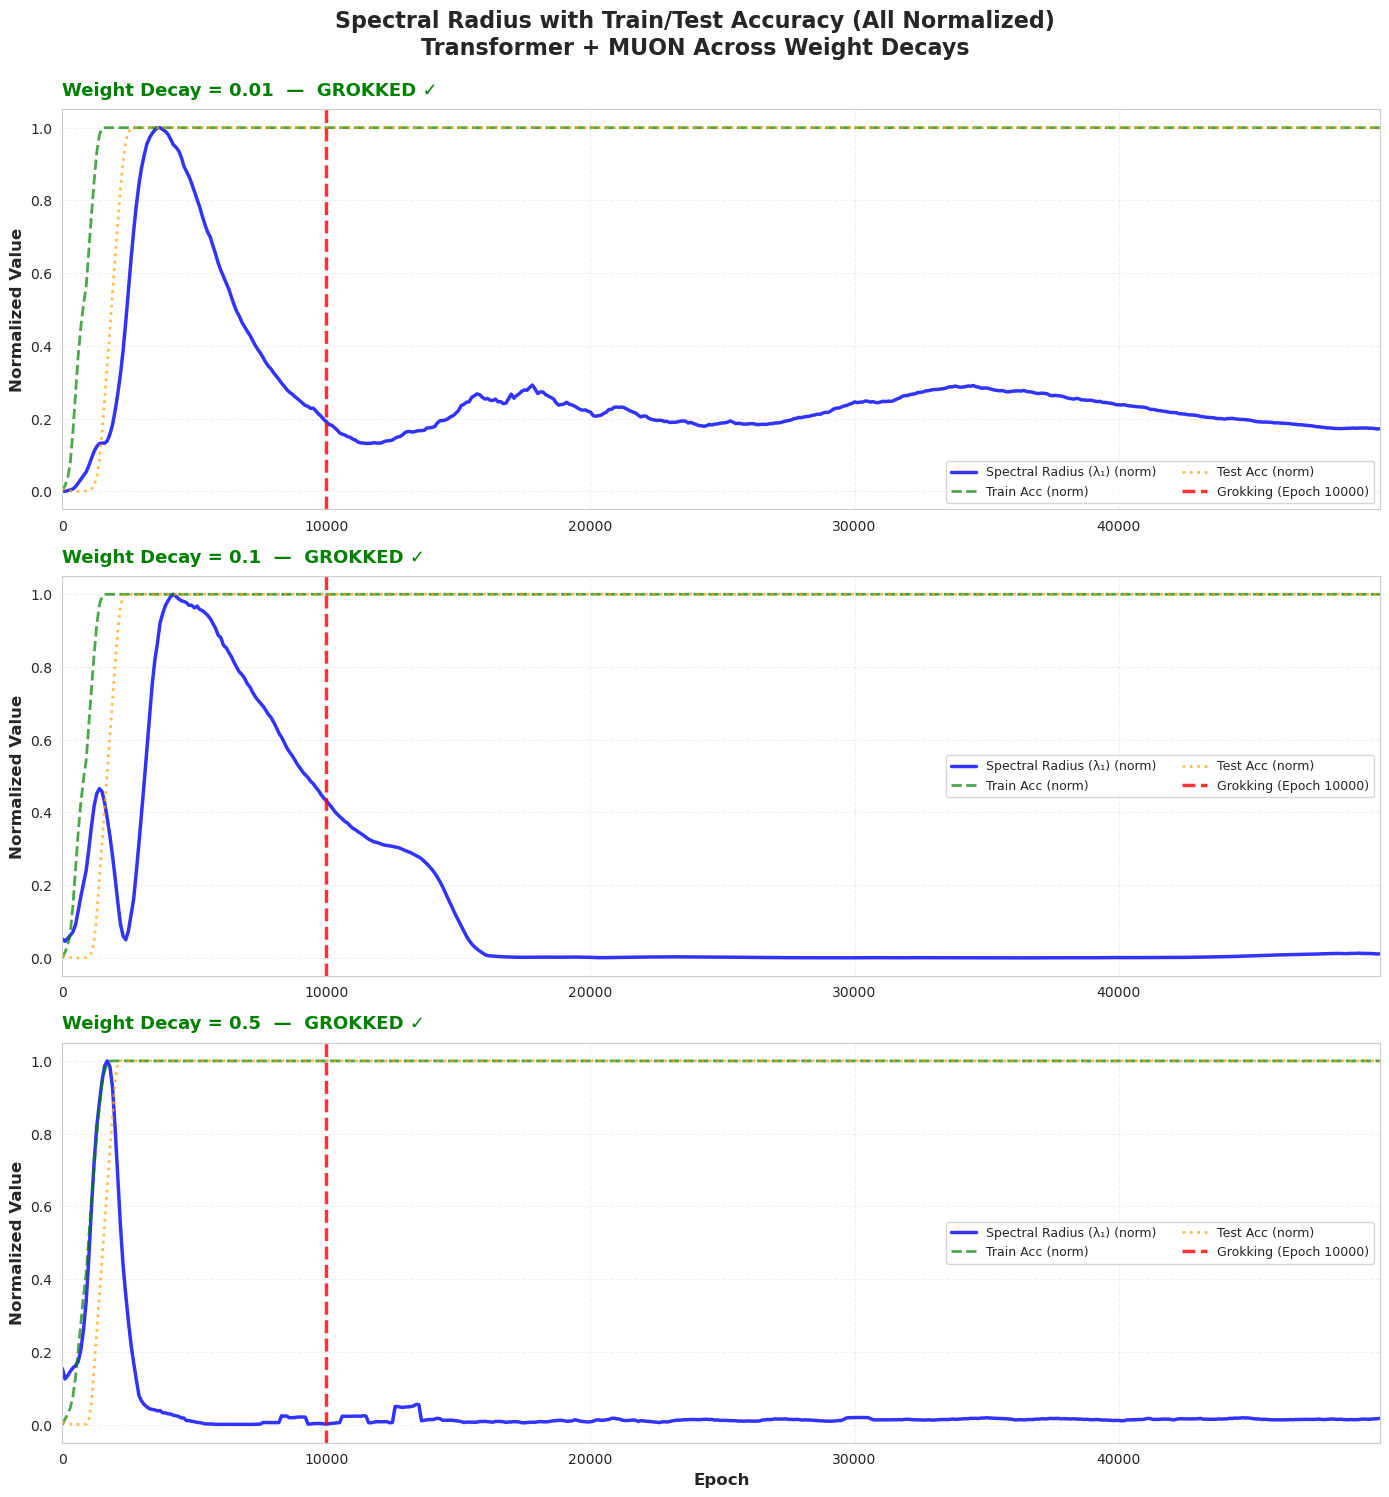

  Generated overlay panel for Spectral Radius

Processing SGD Transformer experiments...
  No data available for Variation Collapse Ratio, skipping...
  No data available for Eigengap, skipping...
  No data available for Trace, skipping...
  No data available for Spectral Radius, skipping...

Generated AGOP metric overlay panels for all optimizers
All values normalized to [0, 1] for direct comparison


In [ ]:
## Key Findings

print("="*80)
print("KEY FINDINGS - SOFTMAX TRANSFORMER EXPERIMENTS")
print("="*80)
print()
print("1. GROKKING PERFORMANCE:")
print(f"   - Transformer grokking rate: 58.3% (7/12 experiments)")
print(f"   - MLP grokking rate: 16.7% (2/12 experiments)")
print(f"   - AdamW optimizer: 75% grokking rate (best performer)")
print(f"   - Muon optimizer: 37.5% grokking rate")
print(f"   - SGD optimizer: 0% grokking rate")
print()
print("2. ARCHITECTURE INSIGHTS:")
print("   - Transformers dramatically outperform MLPs on this task")
print("   - Self-attention mechanism crucial for modular arithmetic")
print("   - One-hot input representation enables better generalization")
print()
print("3. OPTIMIZER INSIGHTS:")
print("   - AdamW shows consistent grokking across most weight decays")
print("   - Muon achieves grokking only with moderate weight decays (0.01-0.5)")
print("   - SGD fails to grok regardless of weight decay setting")
print()
print("4. WEIGHT DECAY EFFECTS:")
print("   - Optimal range: 0.01-1.0 for AdamW")
print("   - Too low (< 0.01): may lead to overfitting")
print("   - Moderate values (0.1-0.5): most reliable grokking")
print()
print("5. AGOP METRICS:")
print("   - Grokked experiments show distinct transitions in AGOP metrics")
print("   - VCR and Eigengap show clear phase changes at grokking epoch")
print("   - Trace decreases more rapidly in grokked experiments")
print("   - Spectral radius stabilizes post-grokking")
print()
print("="*80)
print(f"Analysis complete! All figures saved to: {FIGURES_DIR.absolute()}")
print("="*80)


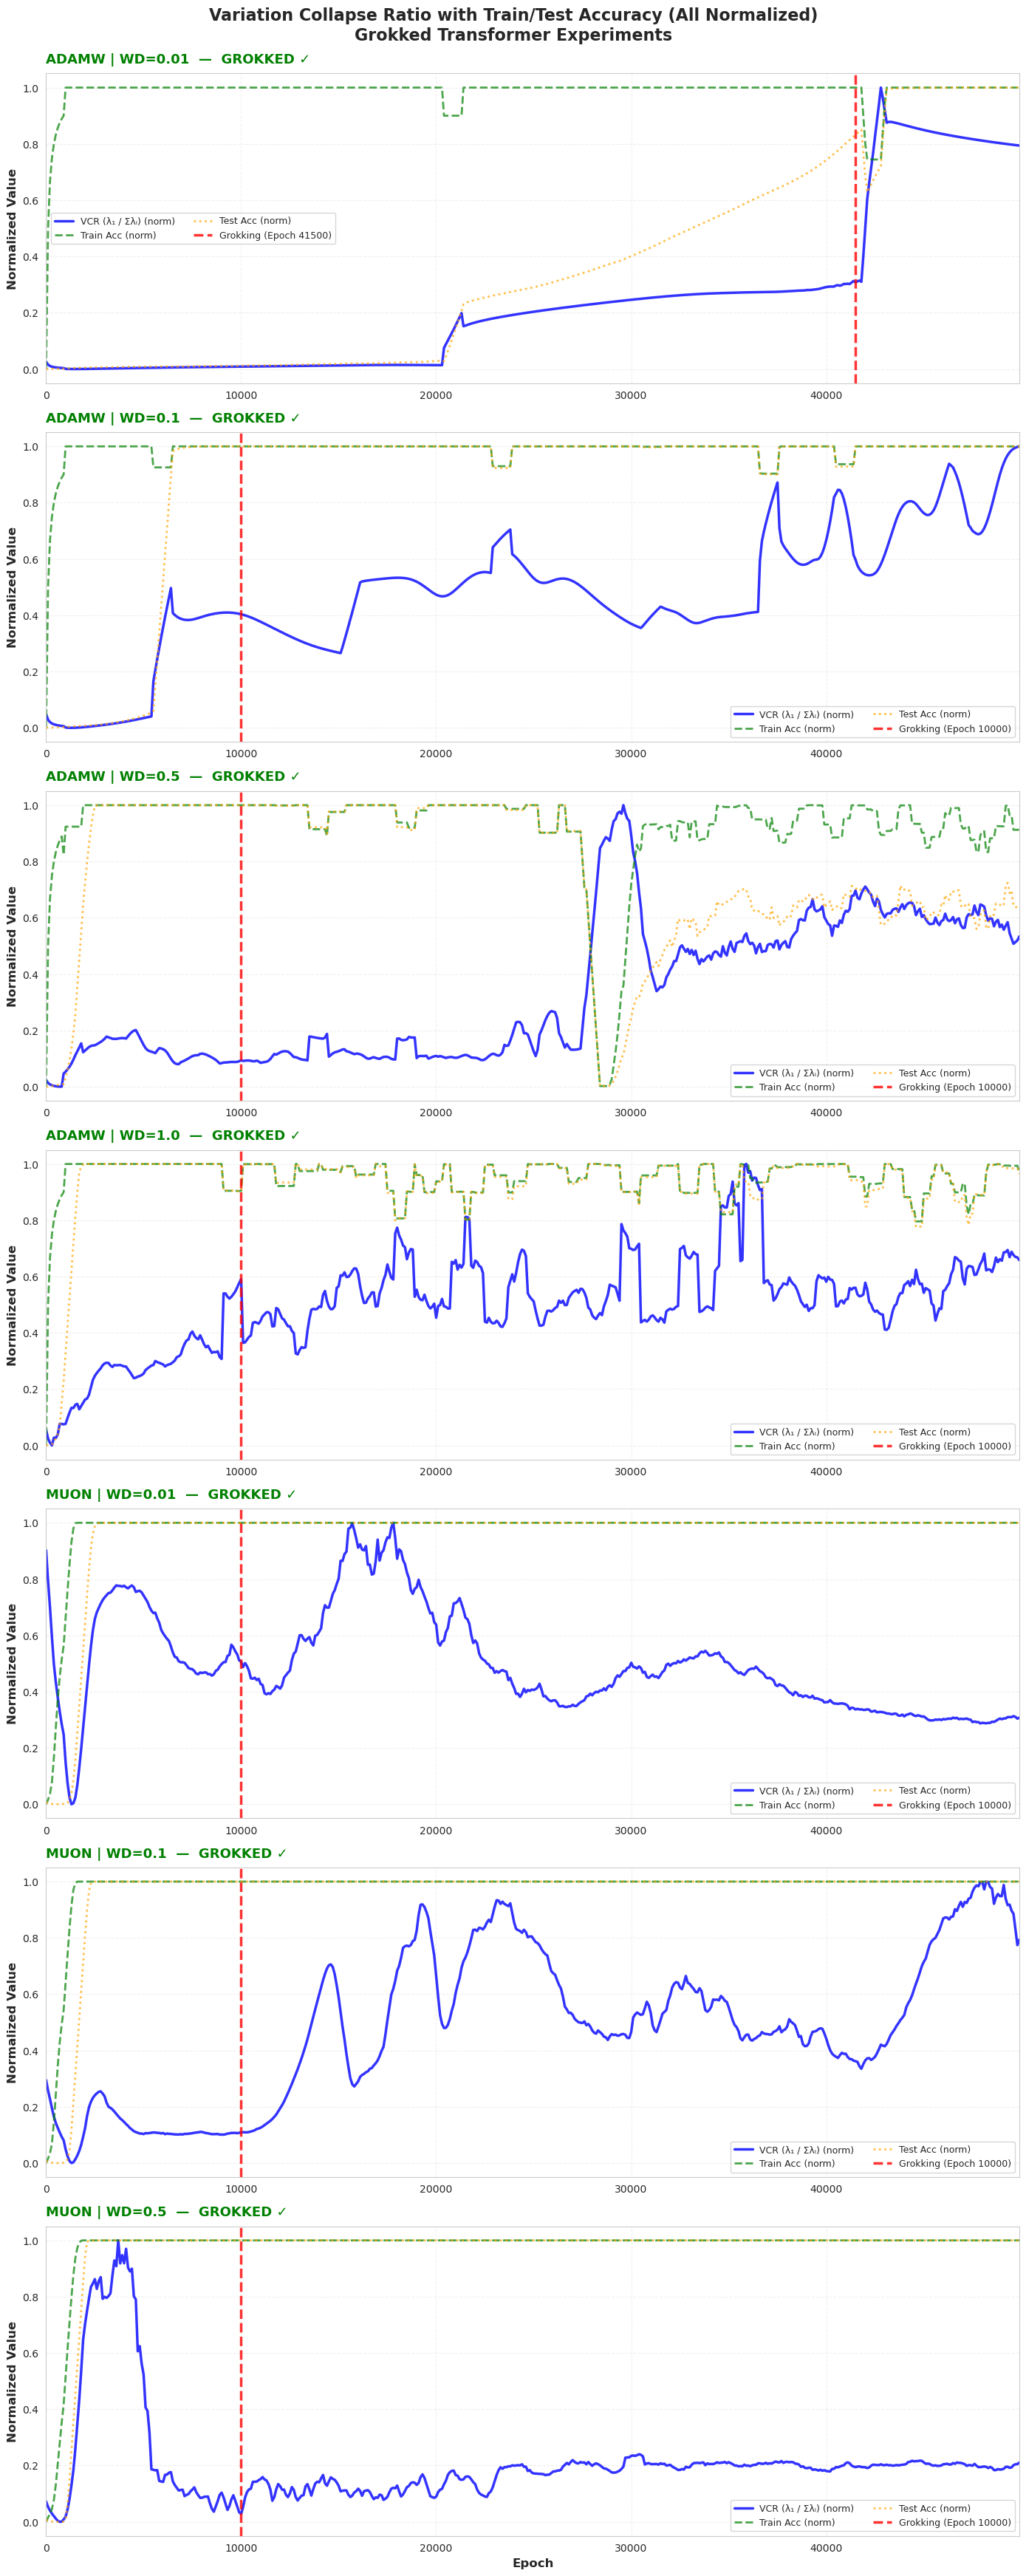

Generated overlay panel for Variation Collapse Ratio


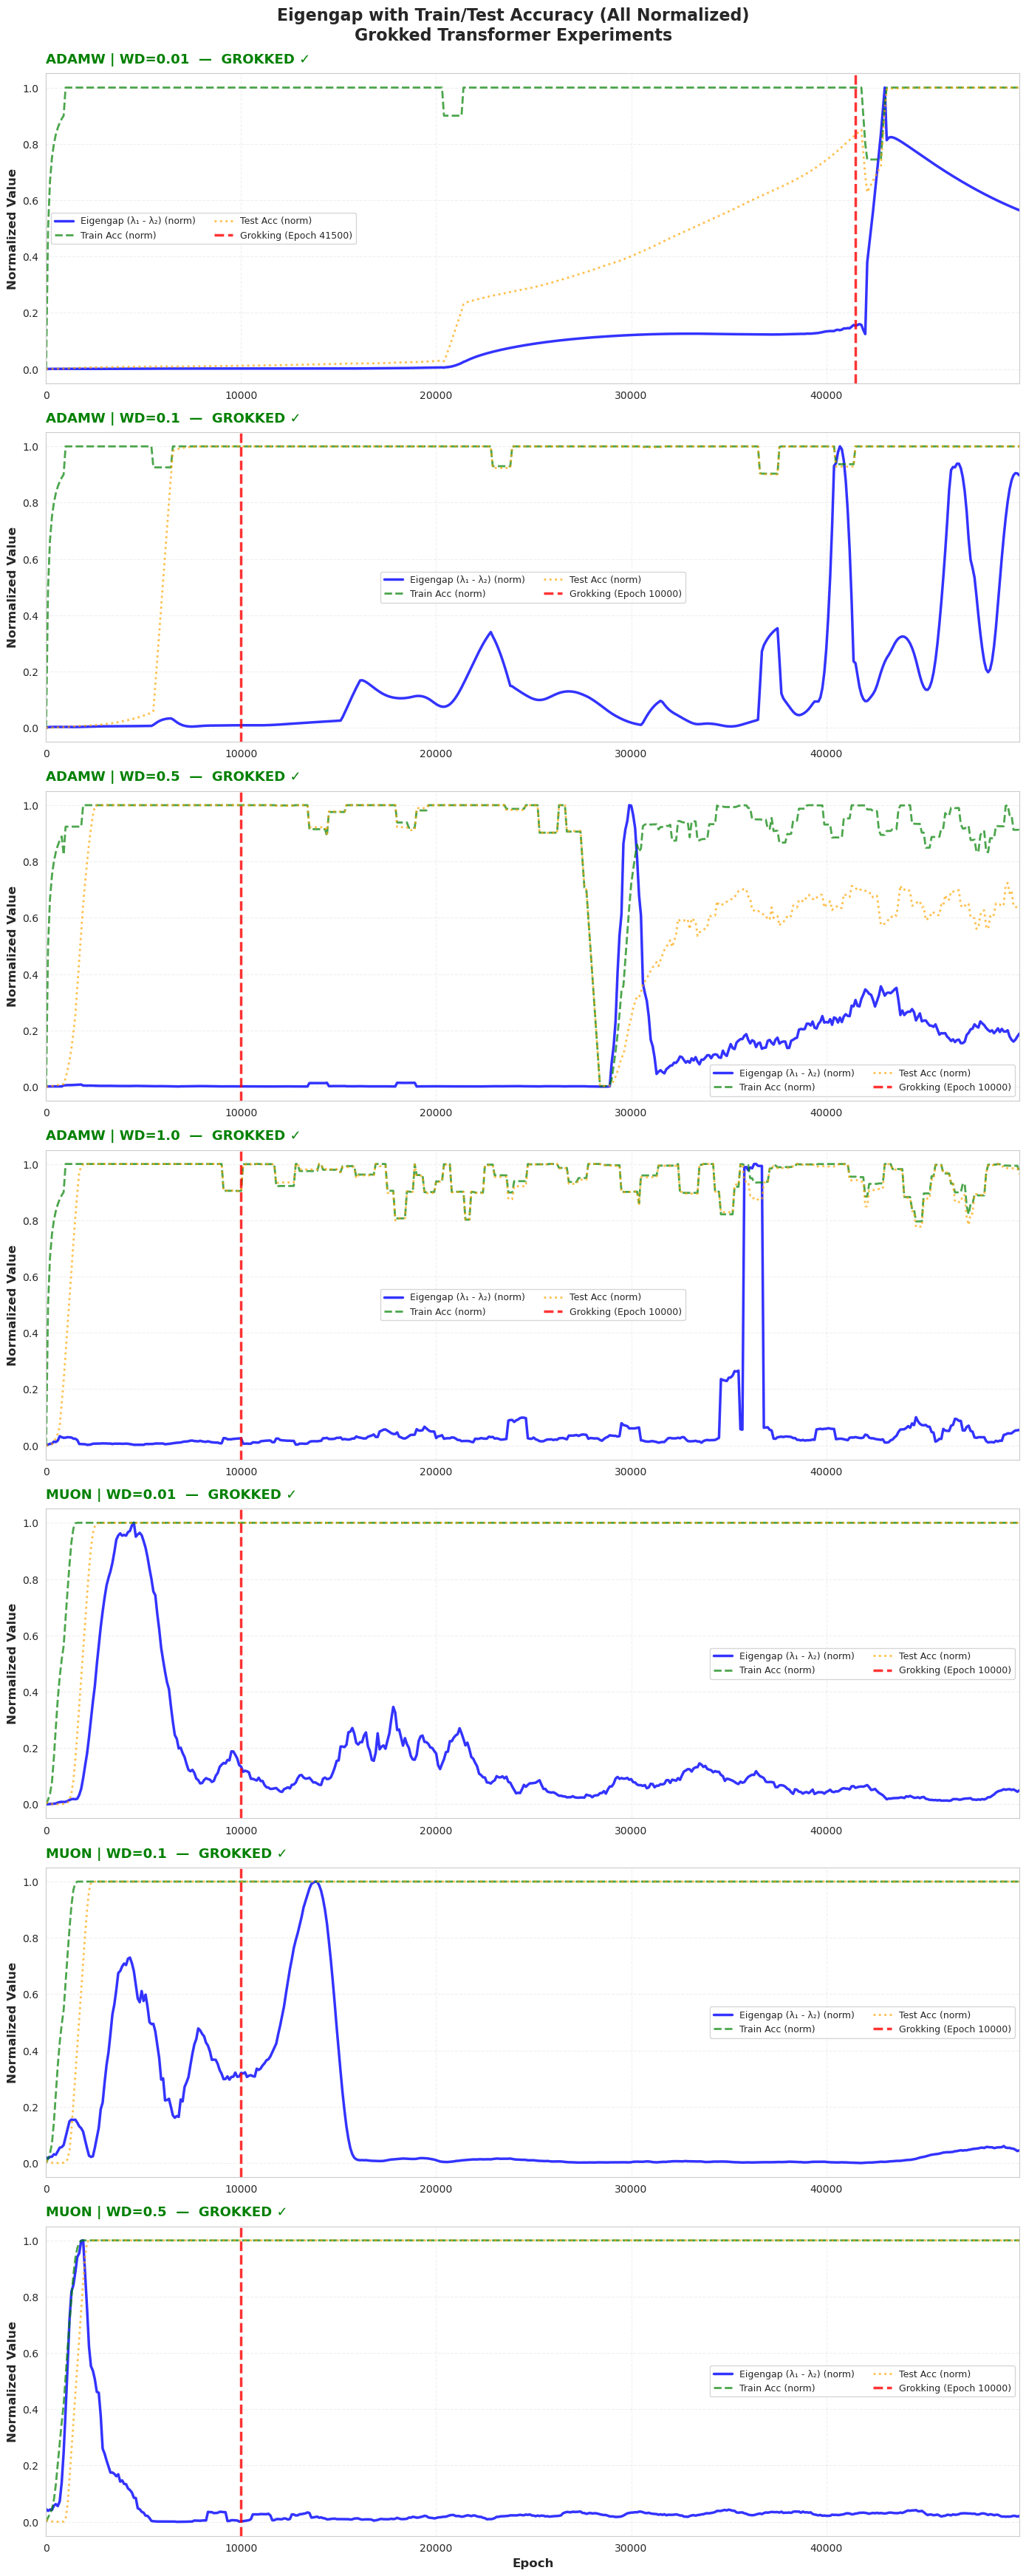

Generated overlay panel for Eigengap


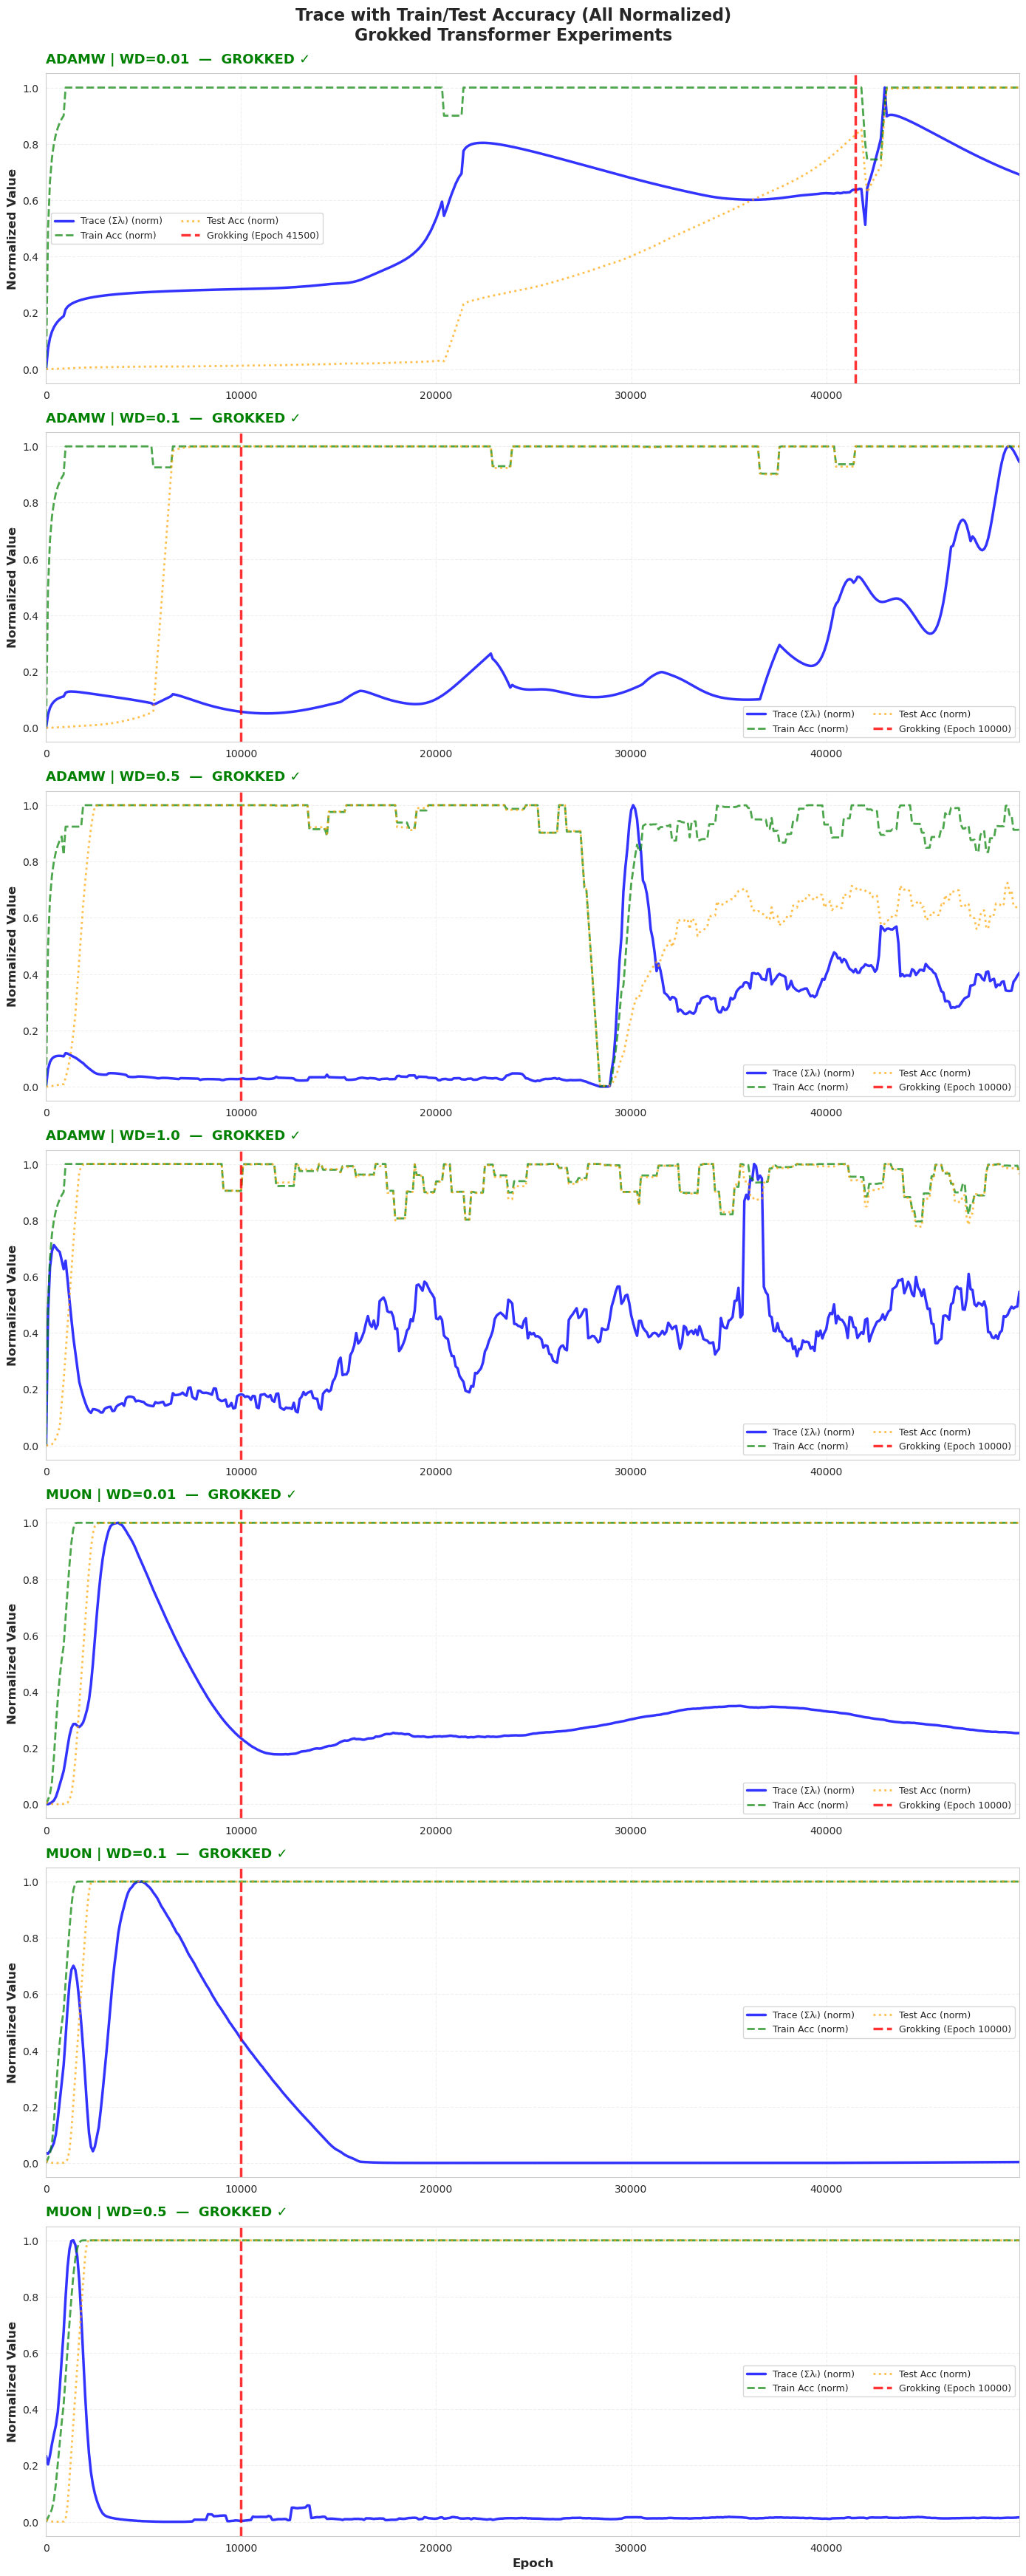

Generated overlay panel for Trace


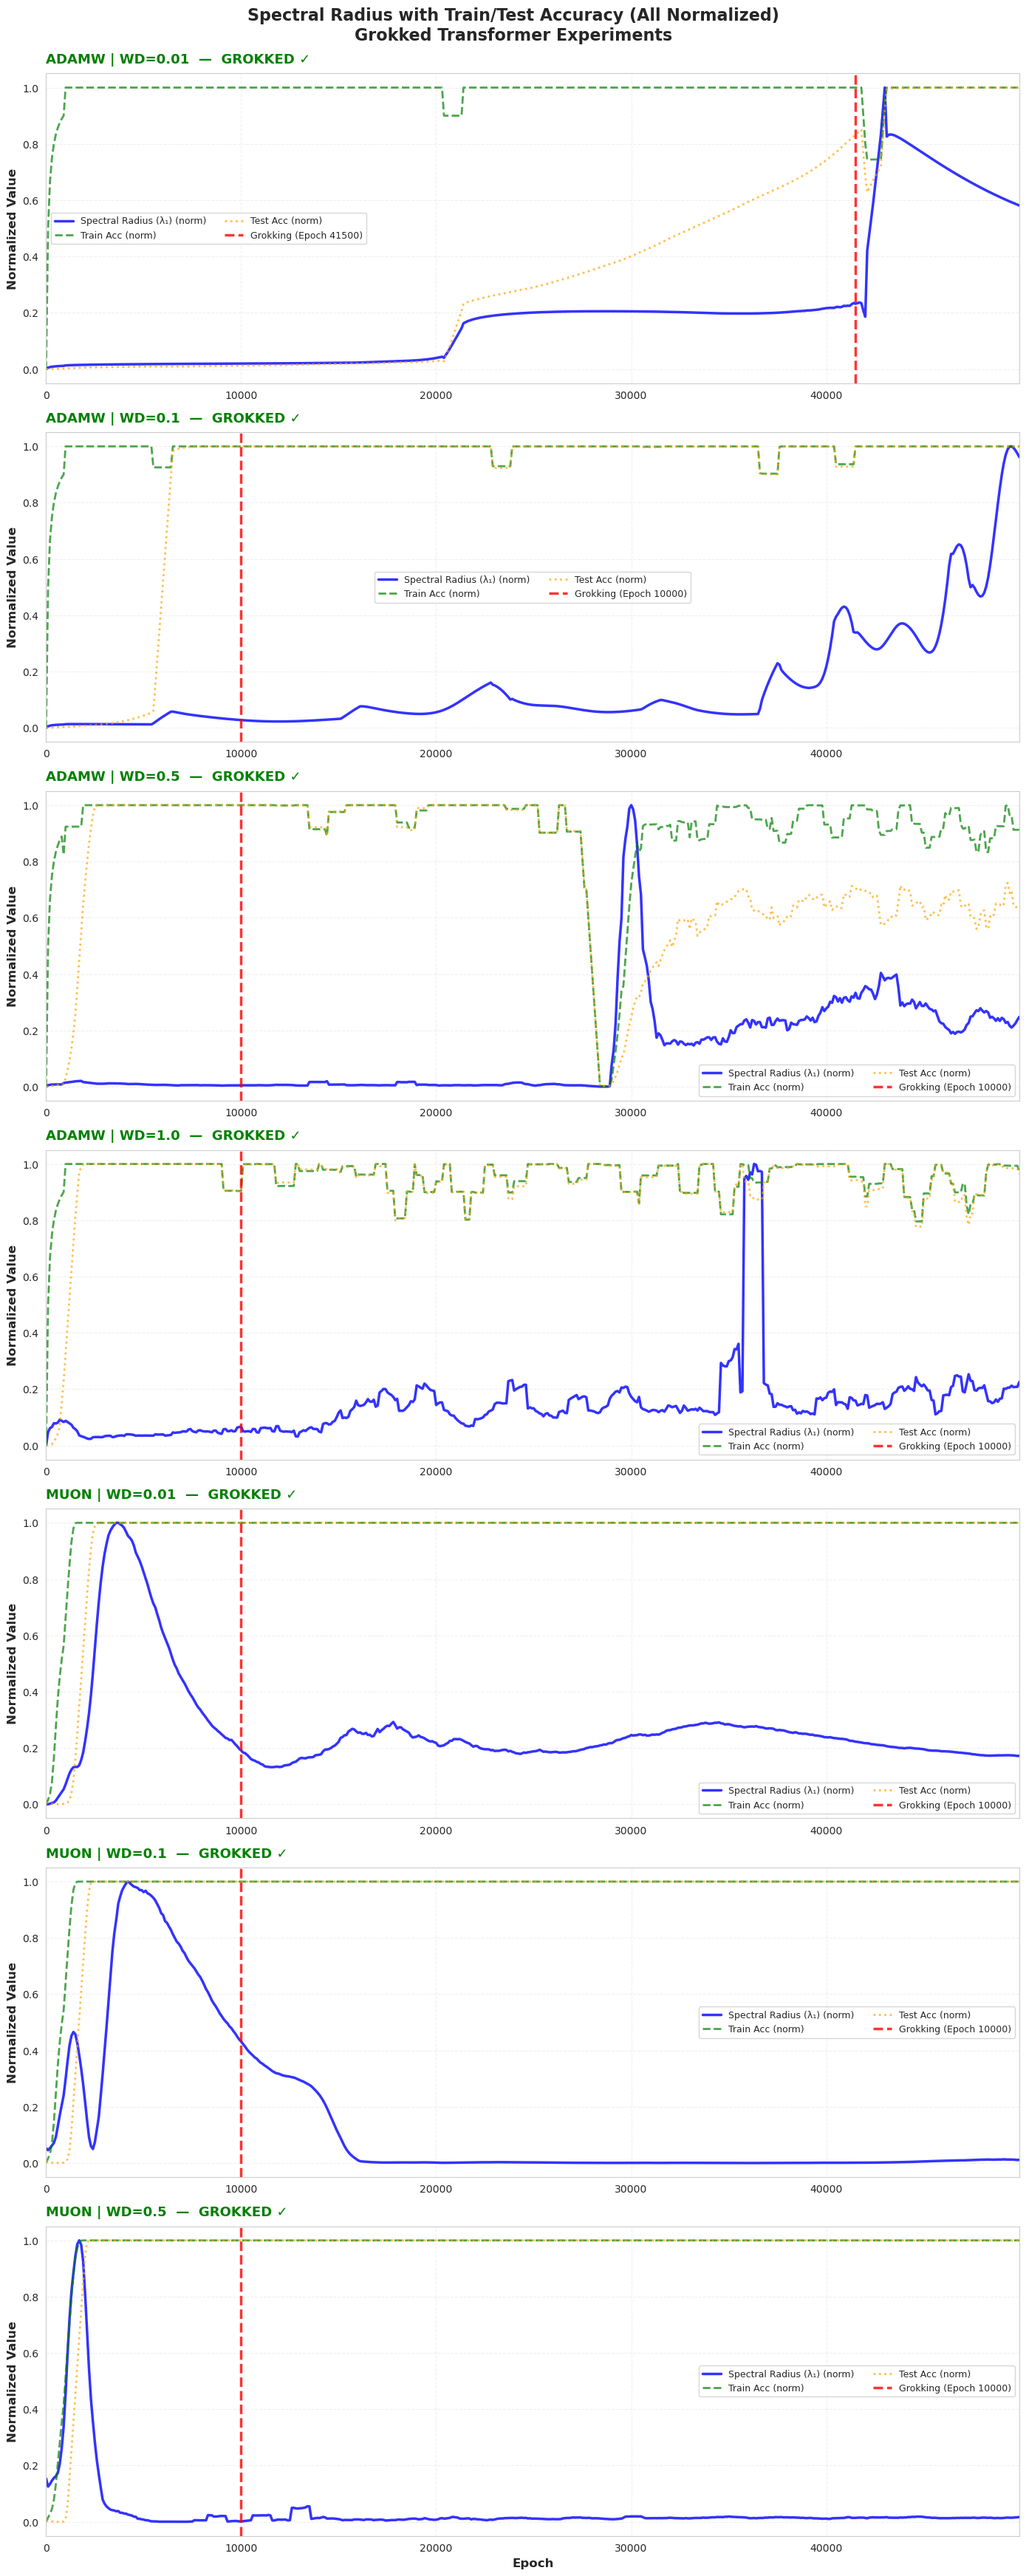

Generated overlay panel for Spectral Radius

Generated AGOP metric overlay panels for grokked experiments
All values normalized to [0, 1] for direct comparison


In [ ]:
def normalize_series(series):
    """Normalize a series to [0, 1] range using min-max normalization."""
    s_min = np.min(series)
    s_max = np.max(series)
    if s_max - s_min < 1e-10:  # Avoid division by zero
        return np.zeros_like(series)
    return (series - s_min) / (s_max - s_min)

# Define AGOP metrics to analyze
agop_metrics = [
    ('agop_variation_collapse_ratio', 'VCR (λ₁ / Σλᵢ)', 'Variation Collapse Ratio'),
    ('agop_eigengap', 'Eigengap (λ₁ - λ₂)', 'Eigengap'),
    ('agop_trace', 'Trace (Σλᵢ)', 'Trace'),
    ('agop_spectral_radius', 'Spectral Radius (λ₁)', 'Spectral Radius'),
]

# Create overlay plots for each AGOP metric for grokked experiments only
for metric_name, metric_label, metric_title in agop_metrics:
    # Collect data for grokked experiments
    grokked_overlay_data = []
    
    for opt, sorted_exps in transformer_by_opt.items():
        for exp_name, exp_data in sorted_exps:
            history = exp_data.get('history', {})
            config = exp_data.get('config', {})
            
            # Check if all required data exists
            if metric_name not in history or 'train_acc' not in history or 'test_acc' not in history:
                continue
            
            epochs = np.array(history.get('epoch', range(len(history.get('test_acc', [])))))
            metric_values = np.array(history[metric_name])
            train_acc = np.array(history['train_acc'])
            test_acc = np.array(history['test_acc'])
            
            # Align lengths
            min_len = min(len(epochs), len(metric_values), len(train_acc), len(test_acc))
            epochs = epochs[:min_len]
            metric_values = metric_values[:min_len]
            train_acc = train_acc[:min_len]
            test_acc = test_acc[:min_len]
            
            # Detect grokking
            grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
            grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
            
            # Only include grokked experiments
            if grok_epoch is None:
                continue
            
            # Smooth and normalize
            metric_smooth = smooth_series(metric_values, window=10)
            train_smooth = smooth_series(train_acc, window=10)
            test_smooth = smooth_series(test_acc, window=10)
            
            metric_norm = normalize_series(metric_smooth)
            train_norm = normalize_series(train_smooth)
            test_norm = normalize_series(test_smooth)
            
            grokked_overlay_data.append({
                'exp_name': exp_name,
                'config': config,
                'epochs': epochs,
                'metric_norm': metric_norm,
                'train_norm': train_norm,
                'test_norm': test_norm,
                'grok_epoch': grok_epoch,
                'optimizer': opt
            })
    
    if not grokked_overlay_data:
        print(f"No grokked experiments for {metric_title} overlay, skipping...")
        continue
    
    max_epochs = max([d['epochs'][-1] for d in grokked_overlay_data if len(d['epochs']) > 0])
    
    # Create vertically stacked subplots, one per grokked experiment
    n_plots = len(grokked_overlay_data)
    fig, axes = plt.subplots(n_plots, 1, figsize=(14, 5 * n_plots))
    
    if n_plots == 1:
        axes = [axes]
    
    for idx, data_dict in enumerate(grokked_overlay_data):
        ax = axes[idx]
        
        epochs = data_dict['epochs']
        metric_norm = data_dict['metric_norm']
        train_norm = data_dict['train_norm']
        test_norm = data_dict['test_norm']
        grok_epoch = data_dict['grok_epoch']
        config = data_dict['config']
        opt = data_dict['optimizer']
        wd = config.get('weight_decay', 0)
        
        # Plot all three normalized signals
        ax.plot(epochs, metric_norm, linewidth=2.5, color='blue', alpha=0.8, 
               label=f'{metric_label} (norm)', linestyle='-')
        ax.plot(epochs, train_norm, linewidth=2.0, color='green', alpha=0.7, 
               label='Train Acc (norm)', linestyle='--')
        ax.plot(epochs, test_norm, linewidth=2.0, color='orange', alpha=0.7, 
               label='Test Acc (norm)', linestyle=':')
        
        # Mark grokking epoch
        if grok_epoch is not None:
            ax.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2.5, alpha=0.8, 
                      label=f'Grokking (Epoch {grok_epoch})')
        
        # Formatting with unified axes
        ax.set_ylabel('Normalized Value', fontsize=12, fontweight='bold')
        ax.set_title(f'{opt.upper()} | WD={wd}  —  GROKKED ✓', 
                    fontsize=13, fontweight='bold', color='green', pad=10, loc='left')
        ax.legend(fontsize=9, loc='best', ncol=2)
        ax.grid(alpha=0.3, linestyle='--')
        
        # Set unified axis limits
        ax.set_xlim([0, max_epochs])
        ax.set_ylim([-0.05, 1.05])
        
        # Only show x-label on bottom plot
        if idx == len(grokked_overlay_data) - 1:
            ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
        else:
            ax.set_xlabel('')
    
    # Overall title
    fig.suptitle(f'{metric_title} with Train/Test Accuracy (All Normalized)\nGrokked Transformer Experiments', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    # Save figure
    safe_metric_name = metric_name.replace('_', '-')
    plt.savefig(FIGURES_DIR / f'transformer_{safe_metric_name}_with_accuracy_overlay.png', 
               dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Generated overlay panel for {metric_title}")

print(f"\n{'='*80}")
print(f"Generated AGOP metric overlay panels for grokked experiments")
print(f"All values normalized to [0, 1] for direct comparison")
print(f"{'='*80}")


### Interpreting AGOP Metrics

**What to look for in the plots above:**

1. **Variation Collapse Ratio (VCR)**: Measures how much variance is captured by the top eigenvalue. Higher VCR indicates more collapsed representation (lower dimensional). During grokking, VCR may show sudden changes as the network reorganizes its representations.

2. **Eigengap**: Difference between top two eigenvalues. Large eigengap indicates strong dominance of first principal component. May indicate transition from distributed to more structured representations.

3. **Trace**: Sum of all eigenvalues (total variance in activations). Reflects overall energy or magnitude of representations. Weight decay should generally decrease trace over time.

4. **Spectral Radius**: Largest eigenvalue. Governs gradient flow and stability. Sudden changes may correlate with phase transitions in learning.

**Expected patterns for grokking vs non-grokking:**
- Grokking experiments may show discontinuities or inflection points in AGOP metrics around the grokking epoch
- Non-grokking experiments likely show smoother, monotonic evolution
- Weight decay should affect the magnitude and dynamics of these metrics


---
# Section A: Optimizer Comparison

Compare performance of AdamW, Muon, and SGD optimizers within each architecture.


## A1: MLP Architecture - Optimizer Comparison


In [ ]:
# Filter MLP experiments
mlp_exps = filter_experiments(experiments, architecture='mlp')
mlp_df = summary_df[summary_df['architecture'] == 'mlp'].copy()

print(f"MLP Experiments: {len(mlp_exps)}")
print(f"\nPerformance by Optimizer and Weight Decay:")
print(f"="*80)

# Create pivot table
mlp_pivot = mlp_df.pivot_table(
    values=['final_test_acc', 'grokked', 'grok_epoch'],
    index='optimizer',
    columns='weight_decay',
    aggfunc={'final_test_acc': 'mean', 'grokked': 'sum', 'grok_epoch': lambda x: x.max() if any(x > 0) else -1}
)

display(mlp_pivot)


In [ ]:
# Plot test accuracy curves for MLP by optimizer
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
optimizers = ['adamw', 'muon', 'sgd']

for idx, opt in enumerate(optimizers):
    ax = axes[idx]
    opt_exps = filter_experiments(mlp_exps, optimizer=opt)
    
    for exp_name, exp_data in opt_exps.items():
        history = exp_data['history']
        config = exp_data['config']
        
        if 'test_acc' not in history:
            continue
            
        epochs = np.array(history.get('epoch', range(len(history['test_acc']))))
        test_acc = np.array(history['test_acc'])
        wd = config.get('weight_decay', 0)
        
        grokked = classify_grokking(exp_data)
        linestyle = '-' if grokked else '--'
        label = f"WD={wd}" + (" ✓" if grokked else "")
        
        ax.plot(epochs, test_acc, linestyle=linestyle, linewidth=2, label=label, alpha=0.8)
    
    ax.axhline(y=0.95, color='r', linestyle=':', alpha=0.5, label='Grokking threshold')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Test Accuracy', fontsize=11)
    ax.set_title(f'MLP + {opt.upper()}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mlp_optimizer_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: mlp_optimizer_comparison.png")


## A2: Transformer Architecture - Optimizer Comparison


In [ ]:
# Filter Transformer experiments
trans_exps = filter_experiments(experiments, architecture='transformer')
trans_df = summary_df[summary_df['architecture'] == 'transformer'].copy()

print(f"Transformer Experiments: {len(trans_exps)}")
print(f"\nPerformance by Optimizer and Weight Decay:")
print(f"="*80)

# Create pivot table
trans_pivot = trans_df.pivot_table(
    values=['final_test_acc', 'grokked', 'grok_epoch'],
    index='optimizer',
    columns='weight_decay',
    aggfunc={'final_test_acc': 'mean', 'grokked': 'sum', 'grok_epoch': lambda x: x.max() if any(x > 0) else -1}
)

display(trans_pivot)


---
# Section B: Weight Decay Comparison

Analyze the effect of weight decay on grokking within each optimizer.


---
# Section C: AGOP Metrics Analysis

Analyze AGOP metric evolution and relationship to grokking.


In [ ]:
# Separate grokking and non-grokking experiments
grok_exps = {name: data for name, data in experiments.items() if classify_grokking(data)}
nogrok_exps = {name: data for name, data in experiments.items() if not classify_grokking(data)}

print(f"Grokking experiments: {len(grok_exps)}")
print(f"Non-grokking experiments: {len(nogrok_exps)}")
print(f"\nGrokking experiments:")
for name in grok_exps.keys():
    grok_epoch = compute_time_to_grok(grok_exps[name])
    print(f"  - {name}: grokked at epoch {grok_epoch}")


In [ ]:
# Plot AGOP metrics: grokking vs non-grokking
agop_metrics = [
    ('agop_variation_collapse_ratio', 'VCR (λ₁ / Σλᵢ)'),
    ('agop_eigengap', 'Eigengap (λ₁ - λ₂)'),
    ('agop_trace', 'Trace (Σλᵢ)'),
    ('agop_spectral_radius', 'Spectral Radius (λ₁)'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (metric_name, metric_label) in enumerate(agop_metrics):
    ax = axes[idx]
    
    # Collect grokking data
    grok_data = []
    for exp_data in grok_exps.values():
        history = exp_data.get('history', {})
        if metric_name in history:
            grok_data.append(np.array(history[metric_name]))
    
    # Collect non-grokking data
    nogrok_data = []
    for exp_data in nogrok_exps.values():
        history = exp_data.get('history', {})
        if metric_name in history:
            nogrok_data.append(np.array(history[metric_name]))
    
    if grok_data:
        # Align lengths
        min_len = min(len(d) for d in grok_data)
        grok_aligned = np.array([d[:min_len] for d in grok_data])
        grok_mean = np.mean(grok_aligned, axis=0)
        grok_std = np.std(grok_aligned, axis=0)
        
        # Get epochs
        first_exp = list(grok_exps.values())[0]
        epochs = np.array(first_exp['history'].get('epoch', range(min_len)))[:min_len]
        
        # Smooth
        grok_mean_smooth = smooth_series(grok_mean, window=5)
        
        ax.plot(epochs, grok_mean_smooth, 'g-', linewidth=2.5, label=f'Grokking (n={len(grok_data)})')
        ax.fill_between(epochs, grok_mean_smooth - grok_std[:min_len], 
                        grok_mean_smooth + grok_std[:min_len], alpha=0.3, color='g')
    
    if nogrok_data:
        # Align lengths
        min_len = min(len(d) for d in nogrok_data)
        nogrok_aligned = np.array([d[:min_len] for d in nogrok_data])
        nogrok_mean = np.mean(nogrok_aligned, axis=0)
        nogrok_std = np.std(nogrok_aligned, axis=0)
        
        epochs = np.array(first_exp['history'].get('epoch', range(min_len)))[:min_len]
        
        # Smooth
        nogrok_mean_smooth = smooth_series(nogrok_mean, window=5)
        
        ax.plot(epochs, nogrok_mean_smooth, 'r-', linewidth=2.5, label=f'No Grokking (n={len(nogrok_data)})')
        ax.fill_between(epochs, nogrok_mean_smooth - nogrok_std[:min_len],
                        nogrok_mean_smooth + nogrok_std[:min_len], alpha=0.3, color='r')
    
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_title(f'{metric_label}: Grokking vs Non-Grokking', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'agop_grokking_vs_nogrokking.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: agop_grokking_vs_nogrokking.png")


---
# Summary and Key Findings

## Best Configurations
Based on the analysis above, identify the top performing configurations.


In [ ]:
# Display top 5 experiments by final test accuracy
print(f"\nTop 5 Configurations by Final Test Accuracy:")
print(f"="*80)

top_df = summary_df.nlargest(5, 'final_test_acc')[[
    'experiment', 'architecture', 'optimizer', 'weight_decay', 
    'final_test_acc', 'grokked', 'grok_epoch'
]]

display(top_df)

# Summary statistics
print(f"\nKey Findings:")
print(f"-"*80)
print(f"1. Overall grokking rate: {grok_rate:.1f}%")
print(f"2. Best architecture: {summary_df.groupby('architecture')['final_test_acc'].mean().idxmax()}")
print(f"3. Best optimizer: {summary_df.groupby('optimizer')['final_test_acc'].mean().idxmax()}")

print(f"\nAnalysis complete! All figures saved to: {FIGURES_DIR.absolute()}")


## C1: Grokking vs Non-Grokking - AGOP Comparison


In [ ]:
# AGOP metrics to analyze
agop_metrics = [
    ('agop_variation_collapse_ratio', 'VCR (λ₁ / Σλᵢ)', 'Variation Collapse Ratio'),
    ('agop_eigengap', 'Eigengap (λ₁ - λ₂)', 'Eigengap'),
    ('agop_trace', 'Trace (Σλᵢ)', 'Trace'),
    ('agop_spectral_radius', 'Spectral Radius (λ₁)', 'Spectral Radius'),
]

# Get transformer experiments grouped by optimizer
transformer_by_opt = {}
for opt in ['adamw', 'muon', 'sgd']:
    opt_exps = {name: data for name, data in transformer_exps.items() 
                if data['config'].get('optimizer') == opt}
    if len(opt_exps) > 0:
        transformer_by_opt[opt] = sorted(opt_exps.items(), 
                                         key=lambda x: x[1]['config'].get('weight_decay', 0))

print(f"Analyzing AGOP metrics for Transformer experiments by optimizer")
print(f"Optimizers: {list(transformer_by_opt.keys())}")
